# Extreme-severity modeling

Notebook 05 retained a conventional Gamma log-link GLM as the severity benchmark. This notebook tests whether explicitly separating ordinary claims from extreme losses improves **conditional arithmetic mean severity**, the quantity needed for expected loss. It uses only the existing 80% development sample and five policy-level folds. No raw data or reserved test records are loaded. Notebook 07 is reserved for full-development refitting and final test evaluation after specifications are frozen.

The approved experiment is deliberately small: thresholds of 5,000, 10,000 and 20,000; a properly upper-truncated Gamma body; a logistic exceedance probability; and a GPD excess distribution with constant scale and shape. Complexity must earn its place through original-dollar OOF calibration and stability. Catastrophic claims remain part of the target throughout.

## 1. Development inputs and reproducibility

Claim identity, policy identity, and fold assignment are inherited from Notebook 05. Multiple claims belonging to one policy stay together. Input hashes are recorded and checked again at the end. Saved artifacts contain component parameters and preprocessing, allowing predictions to be reconstructed without refitting.

In [1]:
from pathlib import Path
import hashlib
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats, optimize, special
import joblib
from IPython.display import display

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent
processed = root / "data/processed"
input_paths = [processed / "05_development_policies.csv", processed / "05_severity_oof.csv",
               root / "models/05_selected_specifications.json"]
input_hashes = {str(p.relative_to(root)): hashlib.sha256(p.read_bytes()).hexdigest()
                for p in input_paths}
policies = pd.read_csv(input_paths[0], dtype={"IDpol": "string"})
benchmark = pd.read_csv(input_paths[1], dtype={"IDpol": "string"})
claims = benchmark[["development_claim_row", "IDpol", "cv_fold", "ClaimAmount", "Gamma GLM"]].merge(
    policies.drop(columns=["cv_fold", "ClaimNb", "Exposure"]),
    on="IDpol", how="left", validate="many_to_one")
assert claims.development_claim_row.is_unique
assert policies.IDpol.is_unique
assert claims.ClaimAmount.gt(0).all()
assert claims[["DrivAge", "BonusMalus", "VehPower"]].notna().all().all()
assert claims.cv_fold.eq(claims.IDpol.map(policies.set_index("IDpol").cv_fold)).all()
assert claims.groupby("IDpol").cv_fold.nunique().eq(1).all()
assert set(claims.cv_fold) == {1, 2, 3, 4, 5}

table_dir = processed / "06_diagnostics"
model_dir = root / "models/06_cv"
plot_dir = root / "images/plots/06_extreme_severity_modeling"
for path in [table_dir, model_dir, plot_dir]:
    path.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

def save_table(frame, name):
    frame.to_csv(table_dir / f"{name}.csv", index=False)
    return frame

def save_plot(fig, name):
    fig.tight_layout()
    fig.savefig(plot_dir / f"{name}.png", dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

thresholds = [5000, 10000, 20000]
folds = [1, 2, 3, 4, 5]
SEED = 202706
BOOTSTRAPS = 200
print(f"Development policies: {len(policies):,}; development claims: {len(claims):,}")
print("Existing policy-level folds verified. Only development inputs loaded.")

Development policies: 542,830; development claims: 21,079
Existing policy-level folds verified. Only development inputs loaded.


## 2. Threshold support and diagnostics

The three thresholds were fixed before fitting this comparison. A lower threshold supplies more excesses but may give a poorer extreme-value approximation; a higher threshold sacrifices precision. Counts below show both fitting and validation support. Mean-excess curves use a small diagnostic grid, not additional candidate thresholds. All fitted distribution diagnostics use each fold's fitting claims.

Notebook 05 gave a reason to scrutinize the body: after diagnostically excluding the largest 20 validation claims per fold, normal-theory lognormal predictions had MAE about 1,213 versus 1,560 for Gamma. Those models were fitted to the entire severity distribution, so this is not a direct comparison of truncated body distributions. The present experiment retains the approved truncated Gamma body; it does not add a lognormal body search.

,threshold,fold,fitting_claims,fitting_exceedances,validation_claims,validation_exceedances,largest_fitting_claim
0,5000,1,16895,775,4184,195,"4,075,400.5600"
1,5000,2,16804,745,4275,225,"1,403,057.4000"
2,5000,3,16914,765,4165,205,"4,075,400.5600"
3,5000,4,16791,809,4288,161,"4,075,400.5600"
4,5000,5,16912,786,4167,184,"4,075,400.5600"
5,10000,1,16895,296,4184,82,"4,075,400.5600"
6,10000,2,16804,297,4275,81,"1,403,057.4000"
7,10000,3,16914,290,4165,88,"4,075,400.5600"
8,10000,4,16791,313,4288,65,"4,075,400.5600"
9,10000,5,16912,316,4167,62,"4,075,400.5600"


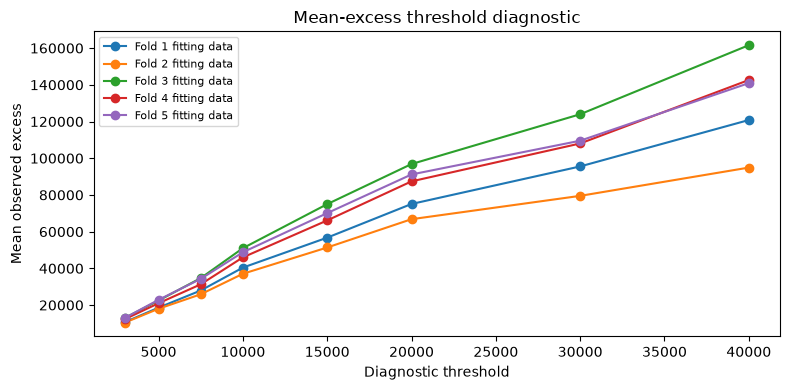

,fold,threshold,n,mean_excess
0,1,3000,1550,"10,697.2597"
1,1,5000,775,"18,590.7642"
2,1,7500,462,"27,939.2442"
3,1,10000,296,"40,415.2545"
4,1,15000,190,"56,735.9930"
5,1,20000,133,"75,084.0462"
6,1,30000,93,"95,532.8660"
7,1,40000,67,"120,812.0436"
8,2,3000,1485,"10,442.0686"
9,2,5000,745,"18,003.0098"


In [2]:
support_rows = []
for u in thresholds:
    for fold in folds:
        fitting = claims[claims.cv_fold != fold]
        validation = claims[claims.cv_fold == fold]
        support_rows.append(dict(threshold=u, fold=fold, fitting_claims=len(fitting),
            fitting_exceedances=int(fitting.ClaimAmount.gt(u).sum()),
            validation_claims=len(validation), validation_exceedances=int(validation.ClaimAmount.gt(u).sum()),
            largest_fitting_claim=fitting.ClaimAmount.max()))
support = save_table(pd.DataFrame(support_rows), "threshold_support")
display(support)

mean_excess_rows = []
diagnostic_grid = [3000, 5000, 7500, 10000, 15000, 20000, 30000, 40000]
fig, ax = plt.subplots(figsize=(8, 4))
for fold in folds:
    y = claims.loc[claims.cv_fold != fold, "ClaimAmount"].to_numpy()
    values = []
    for u in diagnostic_grid:
        excess = y[y > u] - u
        values.append(excess.mean())
        mean_excess_rows.append(dict(fold=fold, threshold=u, n=len(excess), mean_excess=excess.mean()))
    ax.plot(diagnostic_grid, values, marker="o", label=f"Fold {fold} fitting data")
ax.set(xlabel="Diagnostic threshold", ylabel="Mean observed excess", title="Mean-excess threshold diagnostic")
ax.legend(fontsize=8)
save_plot(fig, "mean_excess_by_fitting_fold")
save_table(pd.DataFrame(mean_excess_rows), "mean_excess")

## 3. Statistical specification and predictor ladder

For the Gamma parent distribution, let shape be $k>0$ and scale be $\theta(X)=\exp(Xb)/k$. The body likelihood for $0<Y\leq u$ is

$$\log f_\Gamma(Y;k,\theta(X))-\log F_\Gamma(u;k,\theta(X)).$$

The normalization accounts for upper truncation. The parent mean $\exp(Xb)$ is **not** the body prediction. Instead,

$$\mu_B(X)=k\theta(X)\frac{F_\Gamma(u;k+1,\theta(X))}{F_\Gamma(u;k,\theta(X))}.$$

Logistic regression on all fitting claims estimates $p(X)=P(Y>u\mid X)$. There is no exposure offset: this is a probability conditional on a claim having occurred. The GPD models excess $Z=Y-u$ with location zero, scale $\beta>0$, and constant shape $\xi$. Its conditional tail mean is $\mu_T=u+\beta/(1-\xi)$ when $\xi<1$. Combined expected severity is

$$\mu(X)=(1-p(X))\mu_B(X)+p(X)\mu_T.$$

This is a normalized, nonoverlapping mixture. Exceedance probability is not forced to equal the parent Gamma survival probability, and density continuity at the threshold is not imposed.

| Set | Predictors | Rationale |
|---|---|---|
| M0 | Intercept | Portfolio baseline |
| M1 | Vehicle power | Consistently positive association in the existing Gamma fits |
| M2 | M1 + log driver age + log BonusMalus | Small core with consistent coefficient directions, still subject to tail uncertainty |
| M3 (deferred) | Notebook 05's broader predictor set | Not included in this experiment |

At each threshold, the five combinations are B0/P0, B1/P0, B2/P0, B2/P1, and B2/P2. GPD scale and shape remain constant. This gives 15 candidates, with shared components fitted once per fold. No unrestricted splines are used.

Predictors are standardized within the component's fitting sample. Fixed quadratic penalties on standardized slopes correspond to scales 2 for the body and 1 for the logistic model: the **summed** negative log likelihood adds $\sum b_j^2/(2s^2)$. Intercepts and Gamma shape are unpenalized. These modest penalties are fixed, not tuned. Tail parsimony is stronger: no scale or shape covariates. Logistic probabilities are not class-balanced.

Numerical details: Gamma amounts are divided by $u$ internally, with the density Jacobian restored for scoring. Broad numerical parameter guards are recorded, and a fit hitting one is ineligible. GPD shape is not bounded below 1 or 0.5. Fits use multiple starts, report convergence and gradients, and retain failures rather than dropping difficult folds. Distribution conventions follow [SciPy Gamma](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gamma.html) and [SciPy GPD](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.genpareto.html).

In [3]:
feature_names = {0: [], 1: ["VehPower"], 2: ["VehPower", "log_DrivAge", "log_BonusMalus"]}
configurations = [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2)]

def raw_features(frame, level):
    columns = {"VehPower": frame.VehPower.to_numpy(float),
               "log_DrivAge": np.log(frame.DrivAge.to_numpy(float)),
               "log_BonusMalus": np.log(frame.BonusMalus.to_numpy(float))}
    return np.column_stack([columns[x] for x in feature_names[level]]) if level else np.empty((len(frame), 0))

def make_design(frame, level, preprocessing=None):
    raw = raw_features(frame, level)
    if preprocessing is None:
        preprocessing = {"level": level, "names": feature_names[level],
            "center": raw.mean(axis=0), "scale": np.maximum(raw.std(axis=0), 1e-12),
            "minimum": raw.min(axis=0) if level else np.array([]),
            "maximum": raw.max(axis=0) if level else np.array([])}
    x = np.column_stack([np.ones(len(frame)), (raw-preprocessing["center"])/preprocessing["scale"]])
    return x, preprocessing

def fit_body(frame, u, level):
    x, preprocessing = make_design(frame, level)
    y = frame.ClaimAmount.to_numpy(float)/u
    log_y = np.log(y)
    dimension = x.shape[1]
    def objective(par):
        eta, k = x @ par[:dimension], np.exp(par[-1])
        with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
            rate = k*np.exp(-eta)
            log_cdf = np.log(special.gammainc(k, rate))
            log_density = k*np.log(rate)-special.gammaln(k)+(k-1)*log_y-rate*y
            value = -np.sum(log_density-log_cdf) + np.sum(par[1:dimension]**2)/8
        return float(value) if np.isfinite(value) else 1e100
    bounds = [(-15, 15)] + [(-10, 10)]*(dimension-1) + [(-8, 8)]
    attempts = []
    for initial_shape in [0.5, 2.0, 5.0]:
        start = np.r_[np.log(y.mean()), np.zeros(dimension-1), np.log(initial_shape)]
        result = optimize.minimize(objective, start, method="L-BFGS-B", bounds=bounds,
            options={"maxiter": 1500, "ftol": 1e-12, "gtol": 1e-5, "maxls": 40})
        gradient_per_claim = float(np.max(np.abs(result.jac))/len(y))
        boundary = any(abs(v-lo)<1e-4 or abs(v-hi)<1e-4 for v,(lo,hi) in zip(result.x,bounds))
        ok = bool(result.success and np.isfinite(result.fun) and result.fun < 1e90
                  and gradient_per_claim < 1e-4 and not boundary)
        attempts.append((ok, result, gradient_per_claim, boundary))
    acceptable = [a for a in attempts if a[0]]
    ok, result, gradient, boundary = min(acceptable or attempts, key=lambda a: a[1].fun)
    return dict(kind="truncated_gamma", u=u, level=level, preprocessing=preprocessing,
        coefficients=result.x[:dimension], shape=float(np.exp(result.x[-1])),
        success=ok, message=str(result.message), objective=float(result.fun),
        gradient_per_claim=gradient, numerical_boundary=boundary,
        start_objectives=[float(a[1].fun) for a in attempts], n=len(y), penalty_scale=2)

def body_parameters(model, frame):
    x, _ = make_design(frame, model["level"], model["preprocessing"])
    k = model["shape"]
    parent_mean = model["u"]*np.exp(x @ model["coefficients"])
    return k, parent_mean/k

def predict_body(model, frame):
    k, theta = body_parameters(model, frame)
    t = model["u"]/theta
    return k*theta*special.gammainc(k+1,t)/special.gammainc(k,t)

def fit_probability(frame, u, level):
    x, preprocessing = make_design(frame, level)
    target = frame.ClaimAmount.gt(u).to_numpy(float)
    def objective(b):
        eta = x @ b
        loss = np.sum(np.logaddexp(0,eta)-target*eta) + np.sum(b[1:]**2)/2
        gradient = x.T @ (special.expit(eta)-target) + np.r_[0,b[1:]]
        return loss, gradient
    start = np.r_[special.logit(target.mean()), np.zeros(x.shape[1]-1)]
    result = optimize.minimize(objective,start,jac=True,method="BFGS",options={"gtol":1e-6,"maxiter":1000})
    gradient = float(np.max(np.abs(result.jac))/len(target))
    # BFGS can report precision loss after reaching a stationary point; record both flags.
    ok = bool(np.isfinite(result.fun) and gradient < 1e-7)
    return dict(kind="logistic", u=u, level=level, preprocessing=preprocessing,
        coefficients=result.x, success=ok, optimizer_success=bool(result.success),
        message=str(result.message), gradient_per_claim=gradient, n=len(target), penalty_scale=1)

def predict_probability(model, frame):
    x, _ = make_design(frame,model["level"],model["preprocessing"])
    return special.expit(x @ model["coefficients"])

def fit_gpd(excess, multistart=True):
    # Scale excesses for numerical conditioning; shape remains unrestricted.
    excess = np.asarray(excess, float)
    unit = np.median(excess)
    z = excess/unit
    def objective(par):
        xi, log_scale = par
        if not np.isfinite(log_scale) or abs(log_scale)>50:
            return 1e100
        density = stats.genpareto.logpdf(z, c=xi, loc=0, scale=np.exp(log_scale))
        return -float(density.sum()) if np.isfinite(density).all() else 1e100
    attempts = []
    for xi_start in ([0.1,0.5,0.9,1.2] if multistart else [0.5]):
        result = optimize.minimize(objective,[xi_start,0.0],method="Nelder-Mead",
            options={"maxiter":2000,"xatol":1e-8,"fatol":1e-8})
        attempts.append(result)
    valid = [r for r in attempts if r.success and np.isfinite(r.fun) and r.fun<1e90]
    result = min(valid or attempts, key=lambda r:r.fun)
    xi, beta = float(result.x[0]), float(unit*np.exp(result.x[1]))
    support_ok = bool(np.all(1+xi*excess/beta>0))
    return dict(kind="gpd", xi=xi, beta=beta, success=bool(valid and support_ok),
        message=str(result.message), n=len(excess), objective=float(result.fun)+len(z)*np.log(unit),
        start_objectives=[float(r.fun) for r in attempts],
        finite_mean=xi<1, finite_variance=xi<0.5,
        mean_excess=beta/(1-xi) if xi<1 else np.inf)

def candidate_name(u,b,p):
    return f"BT u={u} B{b}/P{p}"

## 4. Cross-validated component fits and saved predictions

Every validation claim receives predictions from components fitted without its policy. Components are reused only within the same threshold and fitting fold. Each artifact records input hashes, support, optimizer diagnostics, coefficients, and preprocessing. No full-development fit is performed.

Predictions are decomposed into body mean, tail mean, exceedance probability, and their weighted contributions. A nonconverged component or nonfinite GPD mean makes the corresponding complete candidate ineligible; such rows remain in the output and are never silently omitted from pooled scores.

In [4]:
components = {}
fit_rows, prediction_parts, coefficient_rows = [], [], []
for fold in folds:
    training = claims[claims.cv_fold != fold].copy()
    validation = claims[claims.cv_fold == fold].copy()
    assert set(training.IDpol).isdisjoint(set(validation.IDpol))
    for u in thresholds:
        body_data = training[training.ClaimAmount <= u]
        tail = fit_gpd(training.loc[training.ClaimAmount > u,"ClaimAmount"].to_numpy()-u)
        body_models = {level:fit_body(body_data,u,level) for level in [0,1,2]}
        probability_models = {level:fit_probability(training,u,level) for level in [0,1,2]}
        artifact = dict(fold=fold,threshold=u,body=body_models,probability=probability_models,tail=tail,
            input_sha256=input_hashes,software={"numpy":np.__version__,"scipy":scipy.__version__,"pandas":pd.__version__},
            fitting_claim_rows=training.development_claim_row.to_numpy(),
            validation_claim_rows=validation.development_claim_row.to_numpy())
        components[fold,u] = artifact
        joblib.dump(artifact,model_dir/f"components_u{u}_fold{fold}.joblib")
        for kind, models in [("body",body_models),("probability",probability_models)]:
            for level, model in models.items():
                fit_rows.append(dict(fold=fold,threshold=u,component=kind,level=level,n=model["n"],
                    success=model["success"],message=model["message"],
                    gradient_per_claim=model["gradient_per_claim"],
                    shape=model.get("shape",np.nan), numerical_boundary=model.get("numerical_boundary",False)))
                for name,beta,scale in zip(model["preprocessing"]["names"],model["coefficients"][1:],model["preprocessing"]["scale"]):
                    coefficient_rows.append(dict(fold=fold,threshold=u,component=kind,level=level,
                        predictor=name,coefficient_original_transform=beta/scale))
        fit_rows.append(dict(fold=fold,threshold=u,component="tail",level=0,n=tail["n"],
            success=tail["success"],message=tail["message"],xi=tail["xi"],beta=tail["beta"],
            tail_mean=u+tail["mean_excess"],finite_mean=tail["finite_mean"],finite_variance=tail["finite_variance"]))
        for b,p in configurations:
            body_mu = predict_body(body_models[b],validation)
            prob = predict_probability(probability_models[p],validation)
            tail_mu = u+tail["mean_excess"]
            eligible = bool(body_models[b]["success"] and probability_models[p]["success"]
                            and tail["success"] and tail["finite_mean"])
            frame = validation[["development_claim_row","IDpol","cv_fold","ClaimAmount"]].copy()
            frame["model"] = candidate_name(u,b,p)
            frame["threshold"],frame["body_level"],frame["probability_level"] = u,b,p
            frame["body_mean"],frame["tail_probability"],frame["tail_mean"] = body_mu,prob,tail_mu
            frame["body_contribution"],frame["tail_contribution"] = (1-prob)*body_mu,prob*tail_mu
            frame["predicted_severity"] = frame.body_contribution+frame.tail_contribution
            frame["fit_eligible"] = eligible
            assert np.all((body_mu>0)&(body_mu<=u*(1+1e-8)))
            assert np.all((prob>0)&(prob<1))
            prediction_parts.append(frame)
        print(f"Fold {fold}, u={u:,}: tail n={tail['n']}, xi={tail['xi']:.3f}, mean={u+tail['mean_excess']:,.0f}",flush=True)

fits = save_table(pd.DataFrame(fit_rows),"component_fit_diagnostics")
coefficients = save_table(pd.DataFrame(coefficient_rows),"component_coefficients")
oof = pd.concat(prediction_parts,ignore_index=True)
assert not oof.duplicated(["model","development_claim_row"]).any()
assert oof.groupby("model").size().eq(len(claims)).all()
oof.to_csv(processed/"06_body_tail_oof.csv",index=False)
tail_fits = fits[fits.component.eq("tail")].copy()
display(tail_fits[["fold","threshold","n","xi","beta","tail_mean","finite_mean","finite_variance","success"]])
display(fits.groupby("component",as_index=False).agg(fits=("success","size"),acceptable=("success","sum")))

Fold 1, u=5,000: tail n=775, xi=0.858, mean=31,772


Fold 1, u=10,000: tail n=296, xi=0.835, mean=67,542


Fold 1, u=20,000: tail n=133, xi=0.665, mean=88,840


Fold 2, u=5,000: tail n=745, xi=0.894, mean=42,398


Fold 2, u=10,000: tail n=297, xi=0.893, mean=100,023


...

Fold 5, u=5,000: tail n=786, xi=0.901, mean=45,657


Fold 5, u=10,000: tail n=316, xi=0.937, mean=159,839


Fold 5, u=20,000: tail n=146, xi=0.695, mean=104,821


,fold,threshold,n,xi,beta,tail_mean,finite_mean,finite_variance,success
6,1,5000,775,0.8585,"3,789.0229","31,771.9299",True,False,True
13,1,10000,296,0.8354,"9,469.8586","67,541.9549",True,False,True
20,1,20000,133,0.6648,"23,078.2933","88,839.8843",True,False,True
27,2,5000,745,0.8935,"3,982.1297","42,398.4761",True,False,True
34,2,10000,297,0.8933,"9,603.4308","100,023.3756",True,False,True
41,2,20000,135,0.6199,"27,166.3220","91,477.2651",True,False,True
48,3,5000,765,0.9107,"3,650.8316","45,901.0632",True,False,True
55,3,10000,290,0.9882,"8,673.2951","743,685.8739",True,False,True
62,3,20000,133,0.8375,"22,353.4332","157,547.0270",True,False,True
69,4,5000,809,0.8592,"3,894.8874","32,659.8766",True,False,True


,component,fits,acceptable
0,body,45,45
1,probability,45,45
2,tail,15,15


### 4.1 Tail fit and body distribution checks

Approximate threshold stability should appear in shape and in adjusted scale (beta minus xi times threshold), not in raw scale alone. GPD quantile plots and survival curves show fit to fitting excesses. Body probability-integral-transform values use the **truncated** CDF; a uniform distribution would be expected under a correct continuous body distribution. Exact settlement masses prevent literal uniformity, and the plot is descriptive rather than a goodness-of-fit test. No amounts are removed or jittered to hide heaping.

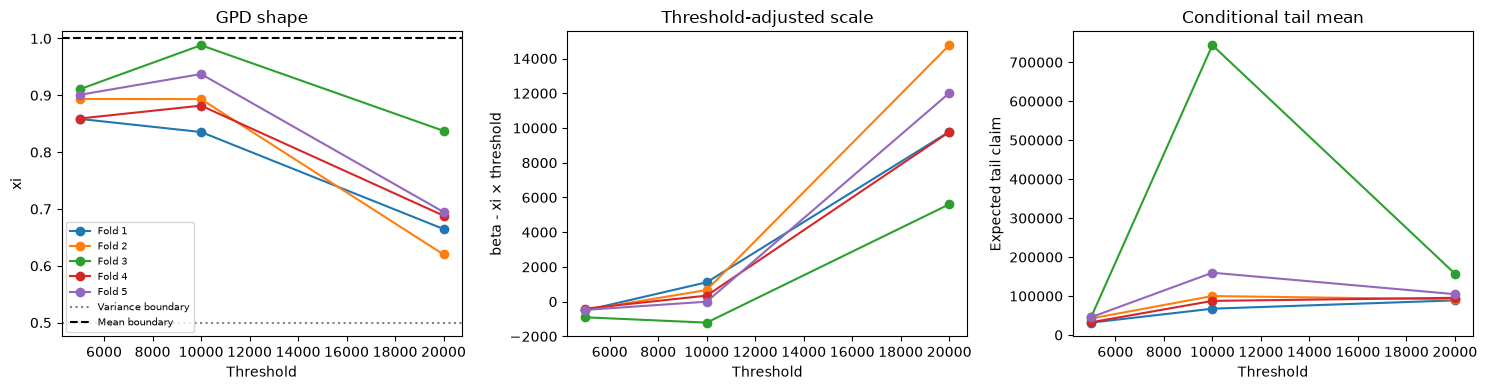

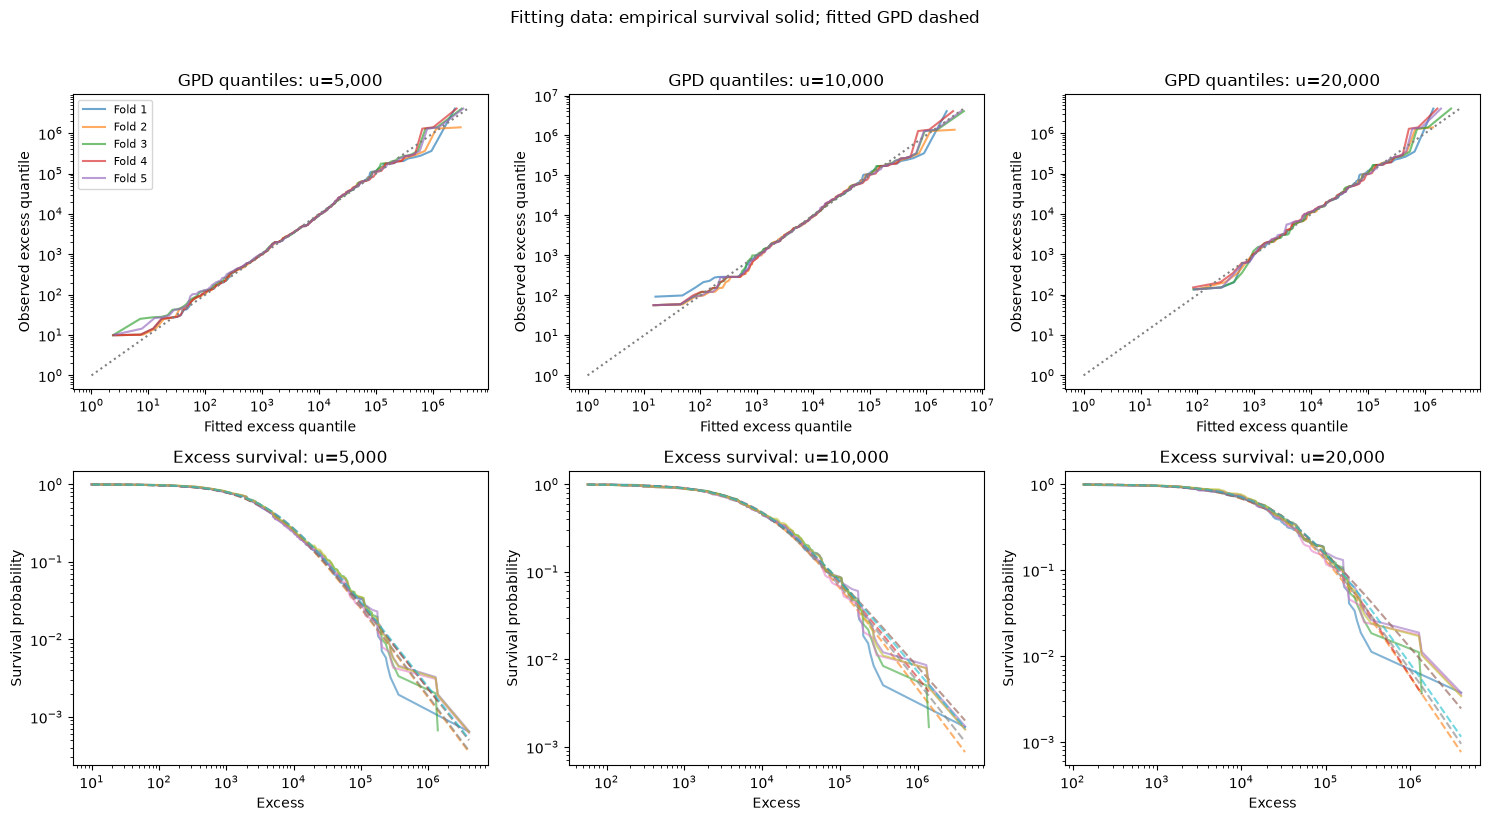

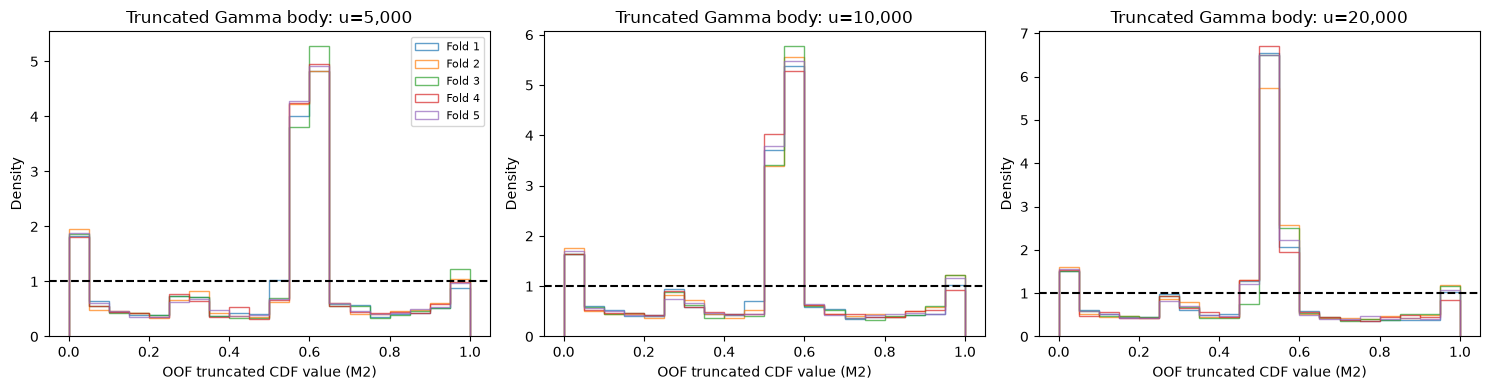

observed_mean  predicted_mean      MAE  \
threshold body_level                                           
5000      0              1,160.5097      1,160.5003 493.7509   
          1              1,160.5097      1,160.4474 493.8219   
          2              1,160.5097      1,160.4727 497.8880   
10000     0              1,328.7162      1,328.6408 721.0400   
          1              1,328.7162      1,328.6343 721.1974   
          2              1,328.7162      1,328.6593 722.1452   
20000     0              1,452.1567      1,451.9730 910.2839   
          1              1,452.1567      1,451.8722 910.3936   
          2              1,452.1567      1,451.9038 910.7035   

                      mean_negative_log_density  
threshold body_level                             
5000      0                              7.9823  
          1                              7.9824  
          2                              7.9812  
10000     0                              8.1613  
          1                              8.1612  
          2                              8.1604  
20000     0                              8.2693  
          1                              8.2692  
          2                              8.2686

In [5]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
for fold in folds:
    rows=tail_fits[tail_fits.fold.eq(fold)].sort_values("threshold")
    axes[0].plot(rows.threshold,rows.xi,marker="o",label=f"Fold {fold}")
    axes[1].plot(rows.threshold,rows.beta-rows.xi*rows.threshold,marker="o")
    axes[2].plot(rows.threshold,rows.tail_mean,marker="o")
axes[0].axhline(0.5,color="grey",linestyle=":",label="Variance boundary")
axes[0].axhline(1,color="black",linestyle="--",label="Mean boundary")
for ax,title,ylabel in zip(axes,["GPD shape","Threshold-adjusted scale","Conditional tail mean"],["xi","beta - xi × threshold","Expected tail claim"]):
    ax.set(title=title,xlabel="Threshold",ylabel=ylabel)
axes[0].legend(fontsize=7)
save_plot(fig,"gpd_threshold_stability")

fig, axes=plt.subplots(2,3,figsize=(15,8))
body_diagnostics=[]
for j,u in enumerate(thresholds):
    for fold in folds:
        training=claims[claims.cv_fold.ne(fold)]
        artifact=components[fold,u]
        z=np.sort(training.loc[training.ClaimAmount.gt(u),"ClaimAmount"].to_numpy()-u)
        probability=(np.arange(len(z))+0.5)/len(z)
        theoretical=stats.genpareto.ppf(probability,c=artifact["tail"]["xi"],scale=artifact["tail"]["beta"])
        axes[0,j].plot(theoretical,z,alpha=.65,label=f"Fold {fold}")
        axes[1,j].plot(z,1-probability,alpha=.55)
        axes[1,j].plot(z,stats.genpareto.sf(z,c=artifact["tail"]["xi"],scale=artifact["tail"]["beta"]),linestyle="--",alpha=.6)
    low=min(axes[0,j].get_xlim()[0],axes[0,j].get_ylim()[0]); high=max(axes[0,j].get_xlim()[1],axes[0,j].get_ylim()[1])
    axes[0,j].plot([max(low,1),high],[max(low,1),high],color="grey",linestyle=":")
    axes[0,j].set(xscale="log",yscale="log",title=f"GPD quantiles: u={u:,}",xlabel="Fitted excess quantile",ylabel="Observed excess quantile")
    axes[1,j].set(xscale="log",yscale="log",title=f"Excess survival: u={u:,}",xlabel="Excess",ylabel="Survival probability")
axes[0,0].legend(fontsize=8)
fig.suptitle("Fitting data: empirical survival solid; fitted GPD dashed",y=1.02)
save_plot(fig,"gpd_quantiles_and_survival")

fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,u in zip(axes,thresholds):
    for fold in folds:
        validation=claims[claims.cv_fold.eq(fold)&claims.ClaimAmount.le(u)]
        model=components[fold,u]["body"][2]
        k,theta=body_parameters(model,validation)
        pit=special.gammainc(k,validation.ClaimAmount.to_numpy()/theta)/special.gammainc(k,u/theta)
        ax.hist(pit,bins=np.linspace(0,1,21),density=True,histtype="step",alpha=.7,label=f"Fold {fold}")
        for level in [0,1,2]:
            model=components[fold,u]["body"][level]
            mu=predict_body(model,validation)
            k,theta=body_parameters(model,validation)
            log_density=stats.gamma.logpdf(validation.ClaimAmount,a=k,scale=theta)-np.log(special.gammainc(k,u/theta))
            body_diagnostics.append(dict(fold=fold,threshold=u,body_level=level,n=len(validation),
                observed_mean=validation.ClaimAmount.mean(),predicted_mean=mu.mean(),
                MAE=np.mean(np.abs(validation.ClaimAmount-mu)),mean_negative_log_density=-log_density.mean()))
    ax.axhline(1,color="black",linestyle="--")
    ax.set(title=f"Truncated Gamma body: u={u:,}",xlabel="OOF truncated CDF value (M2)",ylabel="Density")
axes[0].legend(fontsize=8)
save_plot(fig,"truncated_gamma_body_pit")
body_diagnostics=save_table(pd.DataFrame(body_diagnostics),"body_validation_diagnostics")
display(body_diagnostics.groupby(["threshold","body_level"])[["observed_mean","predicted_mean","MAE","mean_negative_log_density"]].mean())

## 5. Complete expected-severity OOF comparison

The benchmark uses the unchanged Gamma OOF predictions from Notebook 05. All models predict the original claim amount. Pooled means and errors weight claims equally; fold variability is reported separately. A candidate must supply a valid finite prediction for **every** development claim to receive pooled performance metrics. OOF results support development selection and are not an unbiased final evaluation after selection.

,model,n,eligible,observed_mean,predicted_mean,OP,MAE,RMSE,OP_fold_sd,OP_fold_min,OP_fold_max,MAE_fold_sd,RMSE_fold_sd,predicted_mean_fold_sd
0,BT u=10000 B0/P0,21079,True,"2,285.4570","5,340.0744",0.4280,"5,040.6209","32,504.8836",0.3763,0.1452,1.0623,"4,385.8880","22,963.5147","4,898.8285"
1,BT u=10000 B1/P0,21079,True,"2,285.4570","5,340.1073",0.4280,"5,040.5564","32,504.7246",0.3763,0.1452,1.0625,"4,386.1964","22,963.4213","4,899.1120"
2,BT u=10000 B2/P0,21079,True,"2,285.4570","5,340.1375",0.4280,"5,040.8152","32,504.2625",0.3763,0.1452,1.0624,"4,385.5738","22,963.2676","4,898.5367"
3,BT u=10000 B2/P1,21079,True,"2,285.4570","5,347.9257",0.4274,"5,048.3167","32,513.5932",0.3767,0.1447,1.0636,"4,404.5756","22,947.7382","4,918.7860"
4,BT u=10000 B2/P2,21079,True,"2,285.4570","5,353.0476",0.4269,"5,055.8887","32,530.6931",0.3769,0.1445,1.0641,"4,421.6466","22,914.1254","4,930.3202"
5,BT u=20000 B0/P0,21079,True,"2,285.4570","2,314.8392",0.9873,"2,328.3201","32,046.3560",0.2698,0.7651,1.3422,387.2006,"24,052.2298",211.3362
6,BT u=20000 B1/P0,21079,True,"2,285.4570","2,314.7786",0.9873,"2,328.1010","32,046.0947",0.2698,0.7649,1.3420,387.6107,"24,052.2041",211.6299
7,BT u=20000 B2/P0,21079,True,"2,285.4570","2,314.8276",0.9873,"2,327.9599","32,045.0884",0.2699,0.7651,1.3421,387.5411,"24,051.4251",211.3214
8,BT u=20000 B2/P1,21079,True,"2,285.4570","2,315.6421",0.9870,"2,328.6049","32,044.6357",0.2703,0.7630,1.3411,389.0131,"24,050.5218",214.9703
9,BT u=20000 B2/P2,21079,True,"2,285.4570","2,315.5850",0.9870,"2,328.3819","32,045.0281",0.2705,0.7628,1.3415,389.4209,"24,049.1761",215.4240


,model,fold,n,eligible,observed_mean,predicted_mean,OP,MAE,RMSE
0,BT u=10000 B0/P0,1,4184,True,"2,650.6216","2,495.0843",1.0623,"2,860.2821","30,793.3893"
1,BT u=10000 B0/P0,2,4275,True,"2,906.2053","3,063.7571",0.9486,"3,505.1140","62,722.0584"
2,BT u=10000 B0/P0,3,4165,True,"2,039.7350","14,051.1804",0.1452,"12,876.5151","13,922.9609"
3,BT u=10000 B0/P0,4,4288,True,"2,005.4807","2,945.1571",0.6809,"2,567.8196","10,370.3983"
4,BT u=10000 B0/P0,5,4167,True,"1,815.6759","4,289.5208",0.4233,"3,517.6312","7,222.2290"
...,...,...,...,...,...,...,...,...,...
75,Gamma GLM,1,4184,True,"2,650.6216","2,143.7259",1.2365,"2,609.7055","30,782.3869"
76,Gamma GLM,2,4275,True,"2,906.2053","2,116.9550",1.3728,"2,805.7342","62,703.8893"
77,Gamma GLM,3,4165,True,"2,039.7350","2,268.2045",0.8993,"2,060.3587","7,104.7443"
78,Gamma GLM,4,4288,True,"2,005.4807","2,271.1016",0.8830,"2,057.9563","10,355.2179"


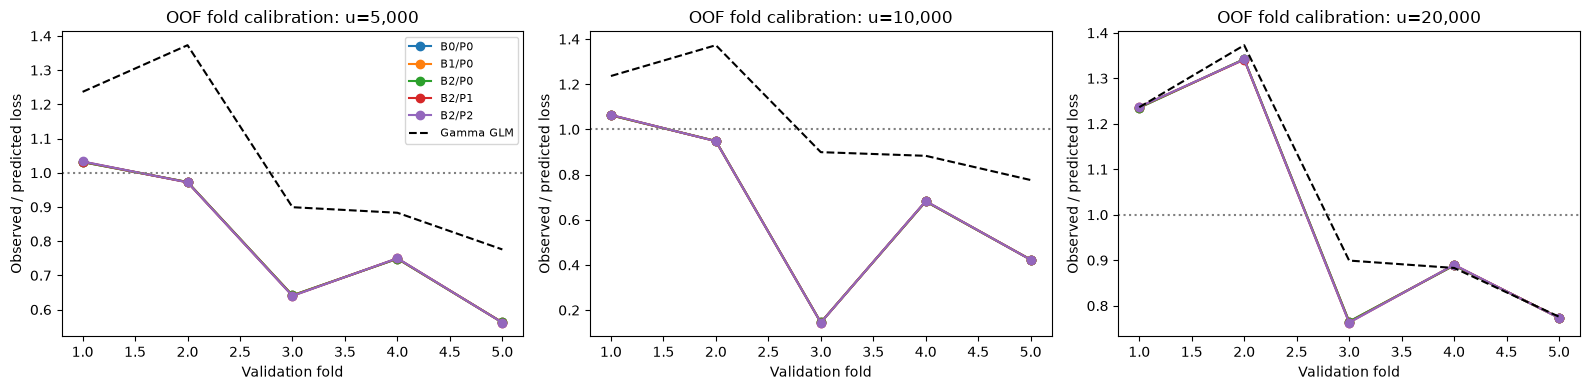

In [6]:
base=claims[["development_claim_row","IDpol","cv_fold","ClaimAmount"]].copy()
base["model"]="Gamma GLM"
base["predicted_severity"]=claims["Gamma GLM"].to_numpy()
base["fit_eligible"]=True
comparison=pd.concat([base,oof[base.columns]],ignore_index=True)

def metrics(frame):
    y=frame.ClaimAmount.to_numpy(float)
    mu=frame.predicted_severity.to_numpy(float)
    valid=bool(frame.fit_eligible.all() and np.isfinite(mu).all() and (mu>0).all())
    return dict(n=len(y),eligible=valid,observed_mean=y.mean(),
        predicted_mean=mu.mean() if valid else np.nan,
        OP=y.sum()/mu.sum() if valid else np.nan,
        MAE=np.abs(y-mu).mean() if valid else np.nan,
        RMSE=np.sqrt(np.mean((y-mu)**2)) if valid else np.nan)

fold_metrics=save_table(pd.DataFrame([dict(model=name,fold=fold,**metrics(rows))
    for (name,fold),rows in comparison.groupby(["model","cv_fold"])]),"severity_fold_metrics")
pooled= pd.DataFrame([dict(model=name,**metrics(rows)) for name,rows in comparison.groupby("model")])
variability=fold_metrics.groupby("model").agg(OP_fold_sd=("OP","std"),OP_fold_min=("OP","min"),
    OP_fold_max=("OP","max"),MAE_fold_sd=("MAE","std"),RMSE_fold_sd=("RMSE","std"),
    predicted_mean_fold_sd=("predicted_mean","std")).reset_index()
pooled=save_table(pooled.merge(variability,on="model"),"severity_pooled")
display(pooled)
display(fold_metrics)

fig,axes=plt.subplots(1,3,figsize=(16,4))
for ax,u in zip(axes,thresholds):
    for b,p in configurations:
        name=candidate_name(u,b,p)
        rows=fold_metrics[fold_metrics.model.eq(name)]
        ax.plot(rows.fold,rows.OP,marker="o",label=f"B{b}/P{p}")
    rows=fold_metrics[fold_metrics.model.eq("Gamma GLM")]
    ax.plot(rows.fold,rows.OP,color="black",linestyle="--",label="Gamma GLM")
    ax.axhline(1,color="grey",linestyle=":")
    ax.set(title=f"OOF fold calibration: u={u:,}",xlabel="Validation fold",ylabel="Observed / predicted loss")
axes[0].legend(fontsize=8)
save_plot(fig,"severity_fold_calibration")

### 5.1 Calibration by predicted severity and exceedance probability

Severity quintiles are constructed separately for each model using its own OOF predictions. Equal predictions stay together (`qcut` drops duplicate edges); no arbitrary tie-breaking creates artificial risk groups. Counts, medians, and largest realized claims make sparse-tail effects visible. Constant intercept predictions can differ across folds, so any groups for an intercept-only model reflect fold-level estimates rather than a covariate ranking.

Exceedance-probability calibration and Brier scores are secondary component diagnostics. They do not replace evaluation of the complete expected-dollar prediction.

,model,quintile,claim_count,observed_mean,predicted_mean,observed_median,largest_claim,OP
0,BT u=10000 B0/P0,1,8472,"2,324.0913","2,722.8832","1,172.0000","1,403,057.4000",0.8535
1,BT u=10000 B0/P0,2,4275,"2,906.2053","3,063.7571","1,172.0000","4,075,400.5600",0.9486
2,BT u=10000 B0/P0,3,4167,"1,815.6759","4,289.5208","1,172.0000","209,695.8700",0.4233
3,BT u=10000 B0/P0,4,4165,"2,039.7350","14,051.1804","1,172.0000","205,432.0500",0.1452
4,BT u=10000 B1/P0,1,4846,"2,536.5548","2,552.9727","1,172.0000","1,403,057.4000",0.9936
...,...,...,...,...,...,...,...,...
72,Gamma GLM,1,4216,"1,829.9883","1,393.1051","1,172.0000","369,131.8800",1.3136
73,Gamma GLM,2,4216,"2,113.3547","1,774.8050","1,172.0000","281,897.4900",1.1908
74,Gamma GLM,3,4215,"1,791.3527","2,073.0992","1,172.0000","183,073.6600",0.8641
75,Gamma GLM,4,4216,"2,092.0049","2,440.5207","1,172.0000","1,301,172.6000",0.8572


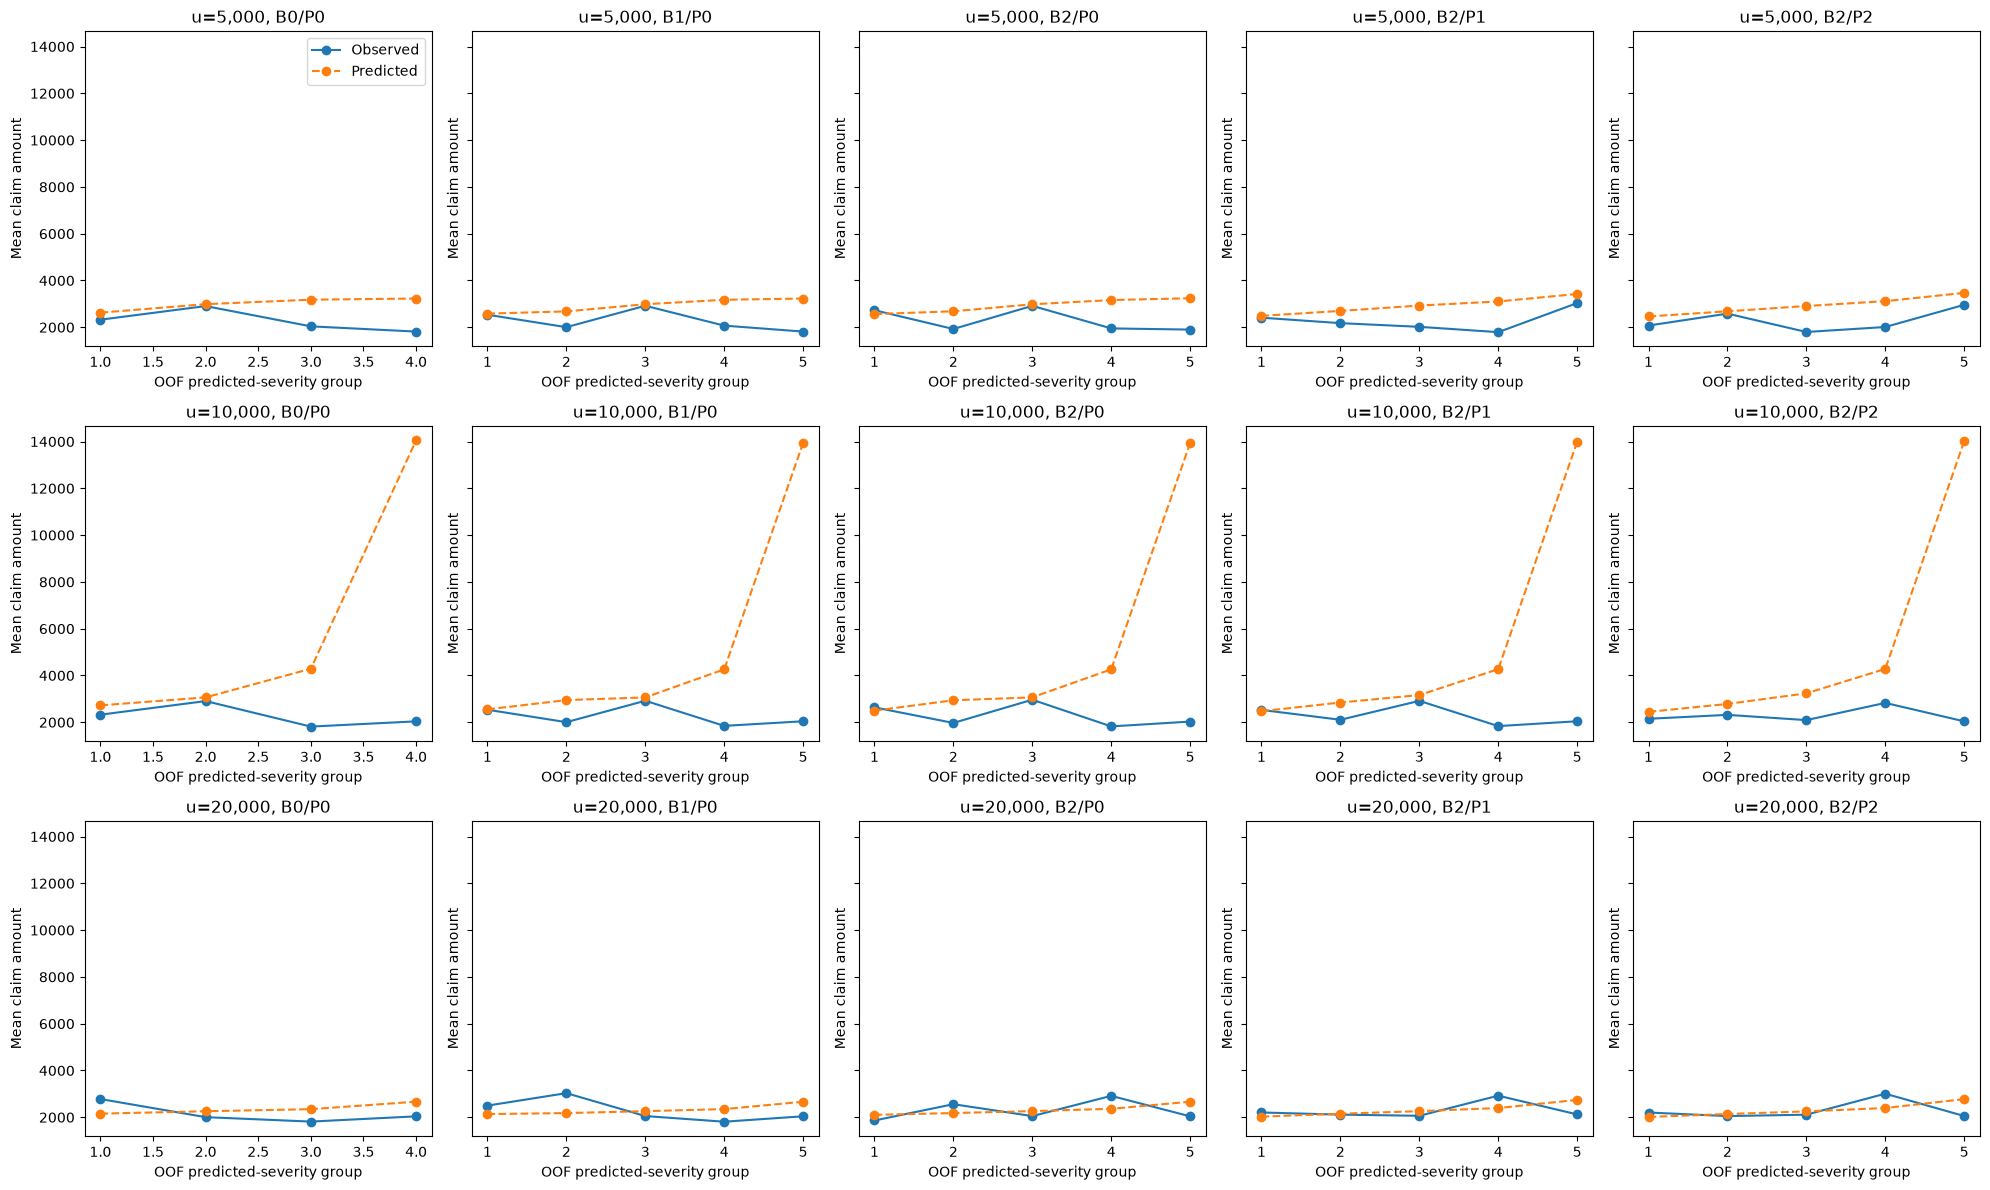

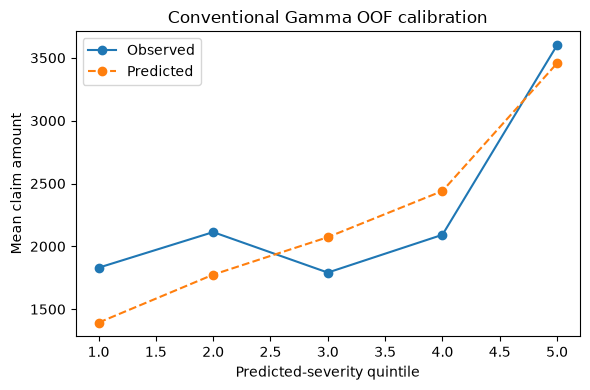

,threshold,probability_level,n,observed_probability,predicted_probability,Brier
0,5000,0,21079,0.0460,0.0460,0.0439
1,5000,1,21079,0.0460,0.0460,0.0439
2,5000,2,21079,0.0460,0.0460,0.0439
3,10000,0,21079,0.0179,0.0179,0.0176
4,10000,1,21079,0.0179,0.0179,0.0176
5,10000,2,21079,0.0179,0.0179,0.0176
6,20000,0,21079,0.0082,0.0082,0.0081
7,20000,1,21079,0.0082,0.0082,0.0081
8,20000,2,21079,0.0082,0.0082,0.0081


,threshold,probability_level,group,n,exceedances,observed_probability,predicted_probability
0,5000,0,1,8440,430,0.0509,0.0448
1,5000,0,2,8351,379,0.0454,0.0462
2,5000,0,3,4288,161,0.0375,0.0482
3,5000,1,1,4914,229,0.0466,0.0403
4,5000,1,2,3519,148,0.0421,0.0430
5,5000,1,3,4653,205,0.0441,0.0452
6,5000,1,4,3961,162,0.0409,0.0476
7,5000,1,5,4032,226,0.0561,0.0550
8,5000,2,1,4217,192,0.0455,0.0385
9,5000,2,2,4215,180,0.0427,0.0423


In [7]:
calibration_rows=[]
for name,rows in comparison.groupby("model"):
    if not metrics(rows)["eligible"]:
        continue
    rows=rows.copy()
    groups=pd.qcut(rows.predicted_severity,q=5,labels=False,duplicates="drop")
    rows["group"]=groups.fillna(0).astype(int)+1
    for group,part in rows.groupby("group"):
        calibration_rows.append(dict(model=name,quintile=group,claim_count=len(part),
            observed_mean=part.ClaimAmount.mean(),predicted_mean=part.predicted_severity.mean(),
            observed_median=part.ClaimAmount.median(),largest_claim=part.ClaimAmount.max(),
            OP=part.ClaimAmount.sum()/part.predicted_severity.sum()))
calibration=save_table(pd.DataFrame(calibration_rows),"severity_calibration")
display(calibration)
fig,axes=plt.subplots(3,5,figsize=(20,12),sharey=True)
for i,u in enumerate(thresholds):
    for j,(b,p) in enumerate(configurations):
        rows=calibration[calibration.model.eq(candidate_name(u,b,p))]
        axes[i,j].plot(rows.quintile,rows.observed_mean,marker="o",label="Observed")
        axes[i,j].plot(rows.quintile,rows.predicted_mean,marker="o",linestyle="--",label="Predicted")
        axes[i,j].set(title=f"u={u:,}, B{b}/P{p}",xlabel="OOF predicted-severity group",ylabel="Mean claim amount")
axes[0,0].legend()
save_plot(fig,"body_tail_oof_calibration")
fig,ax=plt.subplots(figsize=(6,4))
rows=calibration[calibration.model.eq("Gamma GLM")]
ax.plot(rows.quintile,rows.observed_mean,marker="o",label="Observed")
ax.plot(rows.quintile,rows.predicted_mean,marker="o",linestyle="--",label="Predicted")
ax.set(title="Conventional Gamma OOF calibration",xlabel="Predicted-severity quintile",ylabel="Mean claim amount")
ax.legend()
save_plot(fig,"gamma_benchmark_oof_calibration")

probability_rows=[]
probability_calibration=[]
for u in thresholds:
    for p in [0,1,2]:
        rows=oof[oof.model.eq(candidate_name(u,2,p))].copy()
        observed=rows.ClaimAmount.gt(u).to_numpy(float)
        probability_rows.append(dict(threshold=u,probability_level=p,n=len(rows),
            observed_probability=observed.mean(),predicted_probability=rows.tail_probability.mean(),
            Brier=np.mean((observed-rows.tail_probability)**2)))
        rows["group"]=pd.qcut(rows.tail_probability,5,labels=False,duplicates="drop").fillna(0).astype(int)+1
        for group,part in rows.groupby("group"):
            probability_calibration.append(dict(threshold=u,probability_level=p,group=group,n=len(part),
                exceedances=int(part.ClaimAmount.gt(u).sum()),observed_probability=part.ClaimAmount.gt(u).mean(),
                predicted_probability=part.tail_probability.mean()))
probability_metrics=save_table(pd.DataFrame(probability_rows),"exceedance_probability_metrics")
probability_calibration=save_table(pd.DataFrame(probability_calibration),"exceedance_probability_calibration")
display(probability_metrics)
display(probability_calibration)

## 6. Tail sensitivity, parameter uncertainty, and influential losses

### 6.1 Realized validation-tail sensitivity

Within each validation fold, exclude the largest 1, 5, or 20 **observed** claims solely when recomputing diagnostic metrics. Predictions and fitted models are unchanged. This is not a capped target, alternative training set, or proposal to discard catastrophic claims. Pooled sensitivity results use the same excluded claim identities for every model.

,model,removed_per_fold,observed_loss_removed_fraction,n,eligible,observed_mean,predicted_mean,OP,MAE,RMSE
0,BT u=10000 B0/P0,0,0.0000,21079,True,"2,285.4570","5,340.0744",0.4280,"5,040.6209","32,504.8836"
1,BT u=10000 B0/P0,1,0.1300,21074,True,"1,988.8217","5,340.0675",0.3724,"4,745.9132","12,911.1190"
2,BT u=10000 B0/P0,5,0.2318,21054,True,"1,757.8044","5,340.0401",0.3292,"4,522.6150","7,258.4706"
3,BT u=10000 B0/P0,20,0.3269,20979,True,"1,545.6102","5,339.9368",0.2894,"4,339.4991","6,244.2720"
4,BT u=10000 B1/P0,0,0.0000,21079,True,"2,285.4570","5,340.1073",0.4280,"5,040.5564","32,504.7246"
...,...,...,...,...,...,...,...,...,...,...
59,BT u=5000 B2/P2,20,0.3269,20979,True,"1,545.6102","2,928.0193",0.5279,"2,085.4783","2,822.1583"
60,Gamma GLM,0,0.0000,21079,True,"2,285.4570","2,227.6803",1.0259,"2,288.7447","32,039.4398"
61,Gamma GLM,1,0.1300,21074,True,"1,988.8217","2,227.6020",0.8928,"1,992.7171","11,695.9999"
62,Gamma GLM,5,0.2318,21054,True,"1,757.8044","2,227.3749",0.7892,"1,764.0466","4,689.6036"


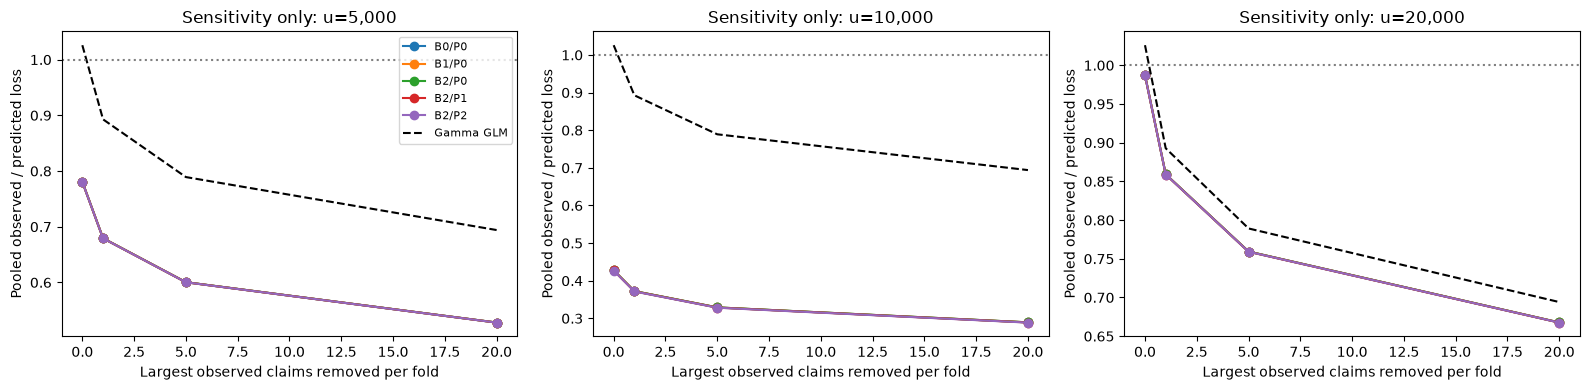

In [8]:
excluded={}
for fold in folds:
    ordered=claims[claims.cv_fold.eq(fold)].sort_values(["ClaimAmount","development_claim_row"],ascending=[False,True])
    for count in [0,1,5,20]:
        excluded[fold,count]=set(ordered.head(count).development_claim_row)
sensitivity_rows=[]
pooled_sensitivity=[]
for name,rows in comparison.groupby("model"):
    for count in [0,1,5,20]:
        retained=[]
        for fold,part in rows.groupby("cv_fold"):
            kept=part[~part.development_claim_row.isin(excluded[fold,count])]
            retained.append(kept)
            sensitivity_rows.append(dict(model=name,fold=fold,removed_per_fold=count,**metrics(kept)))
        kept=pd.concat(retained)
        pooled_sensitivity.append(dict(model=name,removed_per_fold=count,
            observed_loss_removed_fraction=1-kept.ClaimAmount.sum()/rows.ClaimAmount.sum(),**metrics(kept)))
sensitivity=save_table(pd.DataFrame(sensitivity_rows),"tail_sensitivity_by_fold")
sensitivity_pooled=save_table(pd.DataFrame(pooled_sensitivity),"tail_sensitivity_pooled")
display(sensitivity_pooled)
fig,axes=plt.subplots(1,3,figsize=(16,4))
for ax,u in zip(axes,thresholds):
    for b,p in configurations:
        rows=sensitivity_pooled[sensitivity_pooled.model.eq(candidate_name(u,b,p))]
        ax.plot(rows.removed_per_fold,rows.OP,marker="o",label=f"B{b}/P{p}")
    rows=sensitivity_pooled[sensitivity_pooled.model.eq("Gamma GLM")]
    ax.plot(rows.removed_per_fold,rows.OP,color="black",linestyle="--",label="Gamma GLM")
    ax.axhline(1,color="grey",linestyle=":")
    ax.set(title=f"Sensitivity only: u={u:,}",xlabel="Largest observed claims removed per fold",ylabel="Pooled observed / predicted loss")
axes[0].legend(fontsize=8)
save_plot(fig,"validation_tail_sensitivity")

### 6.2 Policy-cluster bootstrap of GPD parameters

Each fitting fold is resampled 200 times at the **claim-bearing policy** level, retaining all claims from each sampled policy. Zero-claim policies provide no observations to this conditional severity likelihood. Only excesses contribute to the GPD fit, but resampling from all claim-bearing policies allows exceedance counts to vary. Threshold and predictor specifications remain fixed. The body and probability models are not refitted in this diagnostic, so these intervals describe tail-parameter uncertainty, not total uncertainty in the complete predictor.

Shape is unrestricted. Failed fits and the fraction of successful fits with $\xi\geq0.5$ or $\xi\geq1$ are reported. A bootstrap tail mean is infinite when $\xi\geq1$; quantiles below use order statistics that retain these infinities. No finite-only tail-mean average is reported. Percentile intervals are approximate and cannot compensate for unobserved catastrophes; 200 resamples provide a diagnostic rather than precise extreme confidence limits.

Tail bootstrap complete: fitting fold 1, 200 policy resamples


Tail bootstrap complete: fitting fold 2, 200 policy resamples


Tail bootstrap complete: fitting fold 3, 200 policy resamples


Tail bootstrap complete: fitting fold 4, 200 policy resamples


Tail bootstrap complete: fitting fold 5, 200 policy resamples


,fold,threshold,resamples,failed,xi_lower,xi_median,xi_upper,fraction_xi_ge_half,fraction_xi_ge_one,tail_mean_lower,tail_mean_median,tail_mean_upper
0,1,5000,200,0,0.7368,0.8524,0.9757,1.0000,0.0100,"19,162.9856","30,972.9045","139,335.1026"
1,1,10000,200,0,0.6119,0.8209,1.0215,1.0000,0.0350,"37,161.9535","63,249.7415",inf
2,1,20000,200,0,0.3417,0.6364,0.9376,0.7750,0.0050,"57,863.5592","85,342.6543","297,764.3827"
3,2,5000,200,0,0.7747,0.8963,1.0173,1.0000,0.0550,"23,630.7594","43,284.9523",inf
4,2,10000,200,0,0.7080,0.8877,1.0619,1.0000,0.1250,"45,383.2925","95,236.4166",inf
5,2,20000,200,0,0.2669,0.6027,0.8257,0.7850,0.0000,"65,119.4980","90,447.8838","170,710.4826"
6,3,5000,200,0,0.7866,0.8934,1.0215,1.0000,0.0700,"22,402.4113","39,304.4461",inf
7,3,10000,200,0,0.7438,0.9662,1.2225,1.0000,0.4050,"50,332.1196","255,147.0781",inf
8,3,20000,200,0,0.4804,0.8186,1.1672,0.9650,0.1650,"68,536.2182","144,480.0312",inf
9,4,5000,200,0,0.7042,0.8545,0.9752,1.0000,0.0050,"19,716.4686","31,433.3725","155,117.8144"


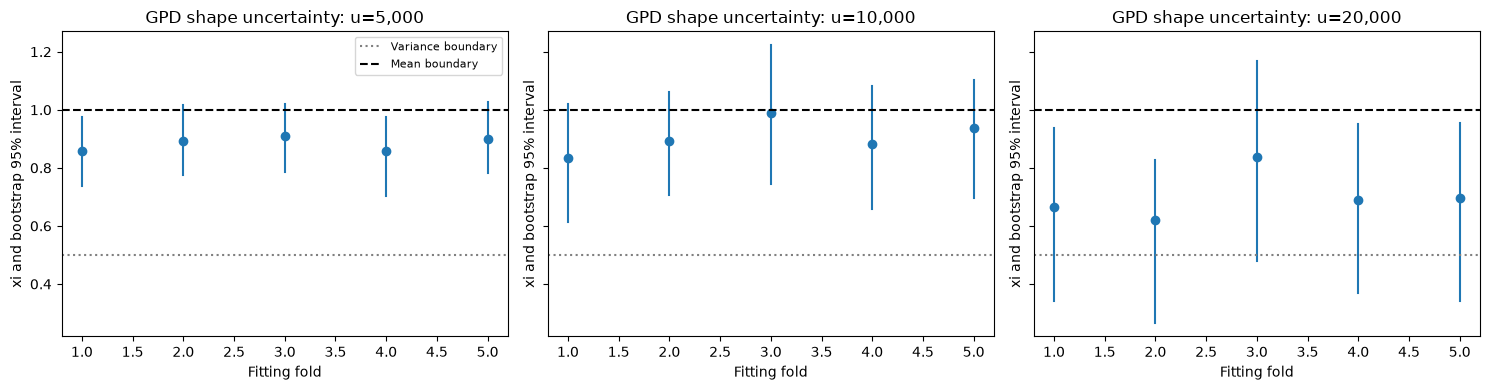

In [9]:
bootstrap_rows=[]
for fold in folds:
    training=claims[claims.cv_fold.ne(fold)]
    policy_codes,unique_policies=pd.factorize(training.IDpol,sort=True)
    y=training.ClaimAmount.to_numpy(float)
    rng=np.random.default_rng(SEED+fold)
    for replicate in range(BOOTSTRAPS):
        counts=rng.multinomial(len(unique_policies),np.full(len(unique_policies),1/len(unique_policies)))
        row_weights=counts[policy_codes]
        for u in thresholds:
            mask=y>u
            excess=np.repeat(y[mask]-u,row_weights[mask])
            fit=fit_gpd(excess,multistart=False)
            bootstrap_rows.append(dict(fold=fold,threshold=u,replicate=replicate,n=len(excess),
                success=fit["success"],xi=fit["xi"],beta=fit["beta"],tail_mean=u+fit["mean_excess"]))
    print(f"Tail bootstrap complete: fitting fold {fold}, {BOOTSTRAPS} policy resamples",flush=True)
bootstrap=save_table(pd.DataFrame(bootstrap_rows),"gpd_policy_bootstrap")

def order_quantile(values,q):
    return np.quantile(np.asarray(values),q,method="inverted_cdf")

uncertainty_rows=[]
for (fold,u),rows in bootstrap.groupby(["fold","threshold"]):
    successful=rows[rows.success]
    uncertainty_rows.append(dict(fold=fold,threshold=u,resamples=len(rows),failed=int((~rows.success).sum()),
        xi_lower=order_quantile(successful.xi,.025),xi_median=order_quantile(successful.xi,.5),
        xi_upper=order_quantile(successful.xi,.975),fraction_xi_ge_half=successful.xi.ge(.5).mean(),
        fraction_xi_ge_one=successful.xi.ge(1).mean(),tail_mean_lower=order_quantile(successful.tail_mean,.025),
        tail_mean_median=order_quantile(successful.tail_mean,.5),tail_mean_upper=order_quantile(successful.tail_mean,.975)))
uncertainty=save_table(pd.DataFrame(uncertainty_rows),"gpd_uncertainty_summary")
display(uncertainty)
fig,axes=plt.subplots(1,3,figsize=(15,4),sharey=True)
for ax,u in zip(axes,thresholds):
    for fold in folds:
        row=uncertainty[(uncertainty.fold.eq(fold))&uncertainty.threshold.eq(u)].iloc[0]
        point=components[fold,u]["tail"]["xi"]
        ax.plot([fold,fold],[row.xi_lower,row.xi_upper],color="C0")
        ax.plot(fold,point,"o",color="C0")
    ax.axhline(.5,color="grey",linestyle=":",label="Variance boundary")
    ax.axhline(1,color="black",linestyle="--",label="Mean boundary")
    ax.set(title=f"GPD shape uncertainty: u={u:,}",xlabel="Fitting fold",ylabel="xi and bootstrap 95% interval")
axes[0].legend(fontsize=8)
save_plot(fig,"gpd_shape_bootstrap_uncertainty")

### 6.3 Influence of the largest fitting losses

This separate diagnostic refits **only the constant GPD** after leaving out the largest 1 or 5 fitting claims. It measures parameter influence, not validation performance. These altered tail fits never generate candidate OOF predictions and are not eligible models. Original full-loss fits and outcomes remain unchanged. The table also reports how much fitting excess is concentrated in the largest claims.

In [10]:
influence_rows=[]
for fold in folds:
    training=claims[claims.cv_fold.ne(fold)]
    for u in thresholds:
        excess=np.sort(training.loc[training.ClaimAmount.gt(u),"ClaimAmount"].to_numpy()-u)[::-1]
        original=components[fold,u]["tail"]
        for removed in [0,1,5]:
            fit=original if removed==0 else fit_gpd(excess[removed:])
            influence_rows.append(dict(fold=fold,threshold=u,omitted_fitting_claims=removed,
                excess_amount_share_omitted=excess[:removed].sum()/excess.sum(),success=fit["success"],
                xi=fit["xi"],beta=fit["beta"],tail_mean=u+fit["mean_excess"],
                original_tail_mean=u+original["mean_excess"]))
influence=save_table(pd.DataFrame(influence_rows),"gpd_influence_diagnostic")
display(influence)

,fold,threshold,omitted_fitting_claims,excess_amount_share_omitted,success,xi,beta,tail_mean,original_tail_mean
0,1,5000,0,0.0000,True,0.8585,"3,789.0229","31,771.9299","31,771.9299"
1,1,5000,1,0.2825,True,0.8315,"3,827.5691","27,721.0750","31,771.9299"
2,1,5000,5,0.3607,True,0.7837,"3,865.5176","22,870.1930","31,771.9299"
3,1,10000,0,0.0000,True,0.8354,"9,469.8586","67,541.9549","67,541.9549"
4,1,10000,1,0.3398,True,0.7705,"9,726.2902","52,379.6720","67,541.9549"
5,1,10000,5,0.4324,True,0.6854,"9,819.4495","41,212.2832","67,541.9549"
6,1,20000,0,0.0000,True,0.6648,"23,078.2933","88,839.8843","88,839.8843"
7,1,20000,1,0.4061,True,0.5068,"24,898.4979","70,487.6247","88,839.8843"
8,1,20000,5,0.5130,True,0.3857,"24,687.8147","60,185.7474","88,839.8843"
9,2,5000,0,0.0000,True,0.8935,"3,982.1297","42,398.4761","42,398.4761"


## 7. Predictor-response stability and component contributions

Curves use one common reference profile: driver age 45, BonusMalus 70, and vehicle power 6. For each threshold, the plotting grid lies inside the intersection of the five body fitting ranges and probability fitting ranges; no GLM curve is plotted beyond component fitting support. These are adjusted responses at a reference profile, not empirical subgroup averages or causal effects. Complete means and exceedance probabilities are shown separately so tail-frequency changes are distinguishable from tail-magnitude changes. GPD scale and shape have no covariates in this experiment.

The support table also identifies validation predictor values outside each component's fitting range. Simple log/linear terms avoid the unrestricted spline mechanism in Notebook 04, but out-of-range predictions still require scrutiny.

,threshold,fold,component,predictor,fitting_min,fitting_max,validation_below,validation_above
26,5000,5,body,log_BonusMalus,3.9120,5.2470,0,3
29,5000,5,probability,log_BonusMalus,3.9120,5.2470,0,3
56,10000,5,body,log_BonusMalus,3.9120,5.2470,0,3
59,10000,5,probability,log_BonusMalus,3.9120,5.2470,0,3
86,20000,5,body,log_BonusMalus,3.9120,5.2470,0,3
89,20000,5,probability,log_BonusMalus,3.9120,5.2470,0,3


,fold,threshold,component,level,predictor,coefficient_original_transform
0,1,5000,body,1,VehPower,0.0007
1,1,5000,body,2,VehPower,0.0021
2,1,5000,body,2,log_DrivAge,0.0982
3,1,5000,body,2,log_BonusMalus,0.2007
4,1,5000,probability,1,VehPower,0.0574
...,...,...,...,...,...,...
115,5,20000,body,2,log_BonusMalus,0.1550
116,5,20000,probability,1,VehPower,0.0572
117,5,20000,probability,2,VehPower,0.0585
118,5,20000,probability,2,log_DrivAge,-0.2345


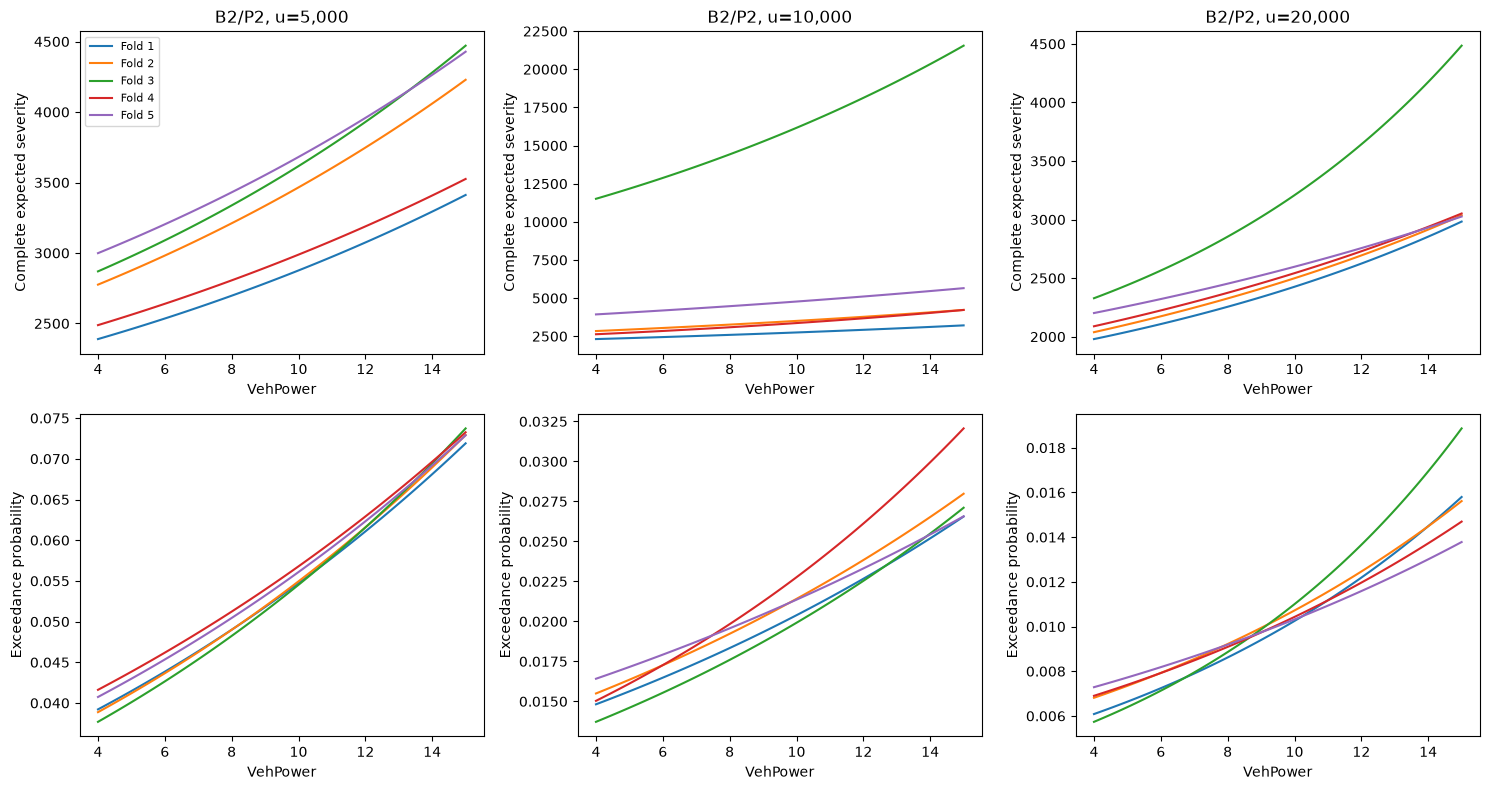

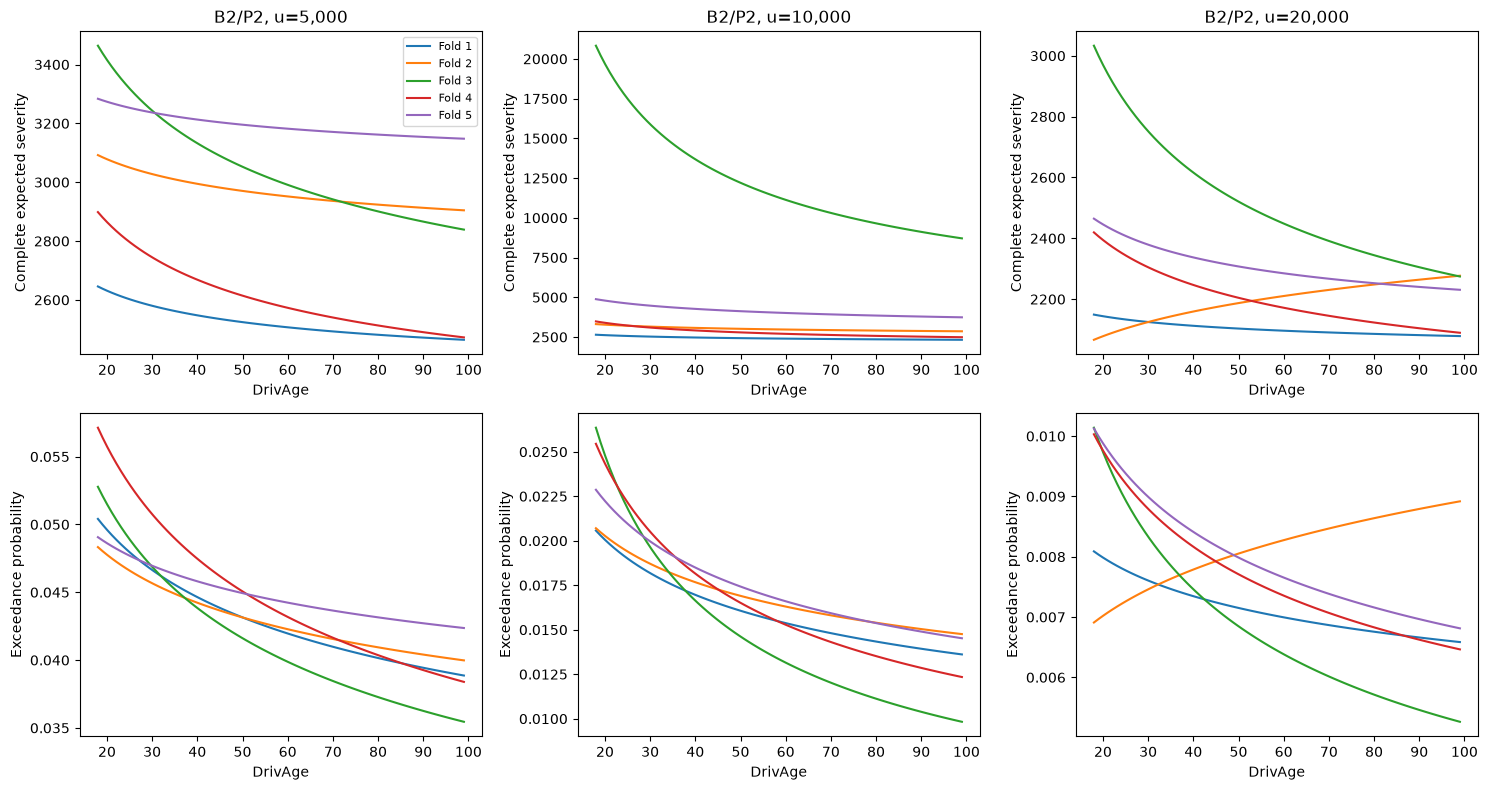

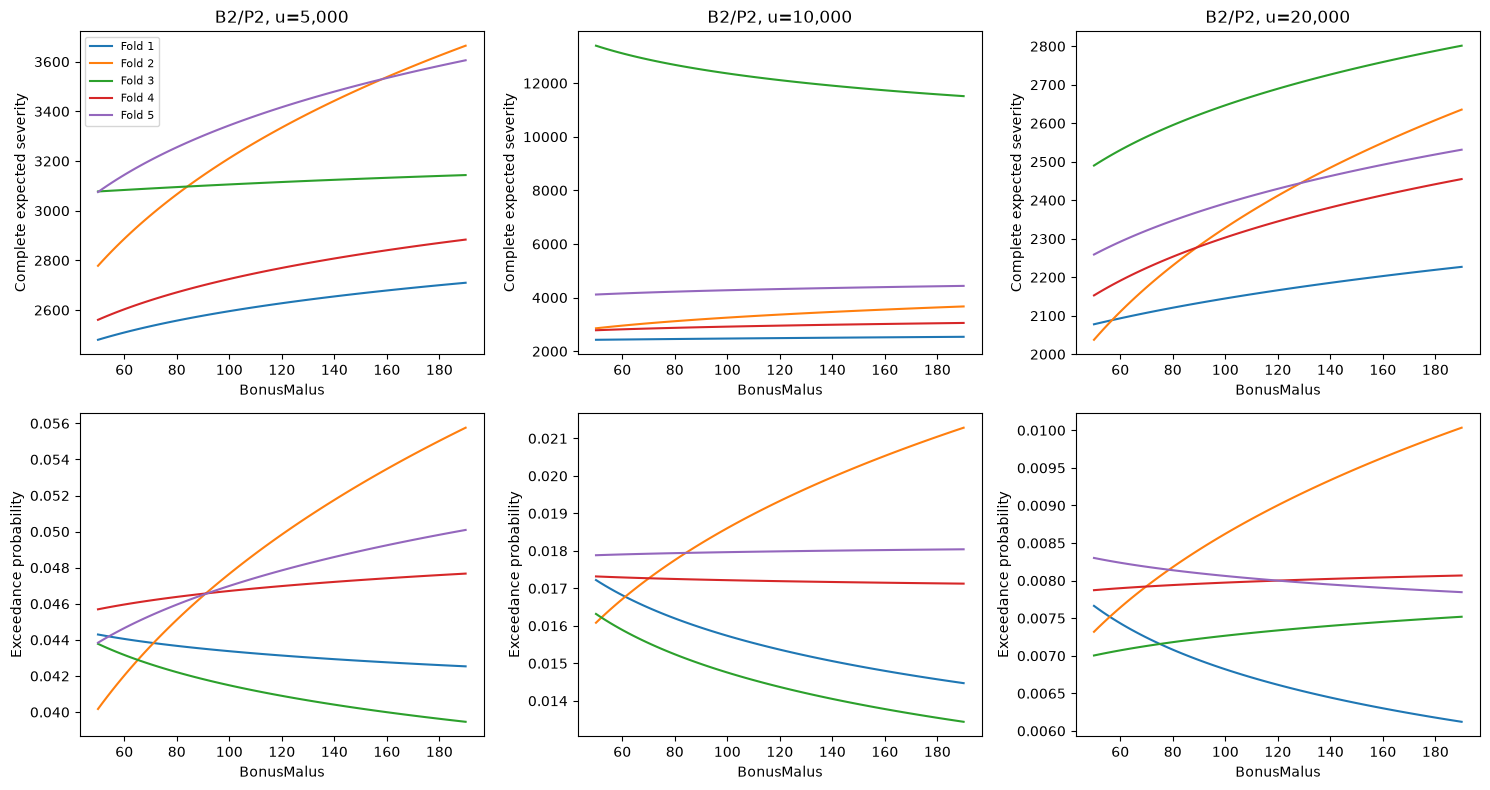

,model,cv_fold,body_contribution,tail_contribution,predicted_mean,observed_mean,predicted_tail_share
0,BT u=10000 B0/P0,1,"1,311.7509","1,183.3335","2,495.0843","2,650.6216",0.4743
1,BT u=10000 B0/P0,2,"1,295.9077","1,767.8495","3,063.7571","2,906.2053",0.5770
2,BT u=10000 B0/P0,3,"1,300.2697","12,750.9107","14,051.1804","2,039.7350",0.9075
3,BT u=10000 B0/P0,4,"1,313.1999","1,631.9572","2,945.1571","2,005.4807",0.5541
4,BT u=10000 B0/P0,5,"1,302.9320","2,986.5888","4,289.5208","1,815.6759",0.6963
...,...,...,...,...,...,...,...
70,BT u=5000 B2/P2,1,"1,113.2999","1,452.7327","2,566.0326","2,650.6216",0.5661
71,BT u=5000 B2/P2,2,"1,107.3902","1,882.8067","2,990.1969","2,906.2053",0.6297
72,BT u=5000 B2/P2,3,"1,102.2346","2,085.1401","3,187.3746","2,039.7350",0.6542
73,BT u=5000 B2/P2,4,"1,105.7129","1,568.3775","2,674.0904","2,005.4807",0.5865


Truncated density normalization, analytic mean, persisted prediction reconstruction, and input hashes verified.


In [11]:
reference={"DrivAge":45.0,"BonusMalus":70.0,"VehPower":6.0}
response_rows=[]
support_diagnostics=[]
for u in thresholds:
    for fold in folds:
        validation=claims[claims.cv_fold.eq(fold)]
        for kind in ["body","probability"]:
            model=components[fold,u][kind][2]
            raw=raw_features(validation,2)
            prep=model["preprocessing"]
            for j,name in enumerate(prep["names"]):
                support_diagnostics.append(dict(threshold=u,fold=fold,component=kind,predictor=name,
                    fitting_min=prep["minimum"][j],fitting_max=prep["maximum"][j],
                    validation_below=int((raw[:,j]<prep["minimum"][j]).sum()),
                    validation_above=int((raw[:,j]>prep["maximum"][j]).sum())))
    for predictor,index,logged in [("VehPower",0,False),("DrivAge",1,True),("BonusMalus",2,True)]:
        minimum=max(components[f,u][kind][2]["preprocessing"]["minimum"][index] for f in folds for kind in ["body","probability"])
        maximum=min(components[f,u][kind][2]["preprocessing"]["maximum"][index] for f in folds for kind in ["body","probability"])
        grid=np.linspace(np.exp(minimum) if logged else minimum,np.exp(maximum) if logged else maximum,80)
        frame=pd.DataFrame({name:np.repeat(value,len(grid)) for name,value in reference.items()})
        frame[predictor]=grid
        for fold in folds:
            artifact=components[fold,u]
            for b,p in configurations:
                body=predict_body(artifact["body"][b],frame)
                probability=predict_probability(artifact["probability"][p],frame)
                tail=u+artifact["tail"]["mean_excess"]
                for value,mu,prob in zip(grid,body,probability):
                    response_rows.append(dict(model=candidate_name(u,b,p),threshold=u,fold=fold,predictor=predictor,
                        value=value,body_mean=mu,tail_probability=prob,tail_mean=tail,
                        predicted_severity=(1-prob)*mu+prob*tail))
responses=save_table(pd.DataFrame(response_rows),"fold_response_curves")
support_diagnostics=save_table(pd.DataFrame(support_diagnostics),"predictor_support")
display(support_diagnostics[support_diagnostics.validation_below.add(support_diagnostics.validation_above).gt(0)])
display(coefficients)
for predictor in ["VehPower","DrivAge","BonusMalus"]:
    fig,axes=plt.subplots(2,3,figsize=(15,8))
    for j,u in enumerate(thresholds):
        rows=responses[responses.model.eq(candidate_name(u,2,2))&responses.predictor.eq(predictor)]
        for fold,part in rows.groupby("fold"):
            axes[0,j].plot(part.value,part.predicted_severity,label=f"Fold {fold}")
            axes[1,j].plot(part.value,part.tail_probability)
        axes[0,j].set(title=f"B2/P2, u={u:,}",xlabel=predictor,ylabel="Complete expected severity")
        axes[1,j].set(xlabel=predictor,ylabel="Exceedance probability")
    axes[0,0].legend(fontsize=8)
    save_plot(fig,f"{predictor.lower()}_fold_response")

contributions=save_table(oof.groupby(["model","cv_fold"],as_index=False).agg(
    body_contribution=("body_contribution","mean"),tail_contribution=("tail_contribution","mean"),
    predicted_mean=("predicted_severity","mean"),observed_mean=("ClaimAmount","mean")),"mean_prediction_components")
contributions["predicted_tail_share"]=contributions.tail_contribution/contributions.predicted_mean
save_table(contributions,"mean_prediction_components")
display(contributions)

# These checks verify the implemented mixture, truncation, and persisted predictions.
example=components[1,10000]
check_frame=claims[claims.cv_fold.eq(1)].head(3)
body_model=example["body"][2]
k,theta=body_parameters(body_model,check_frame)
from scipy.integrate import quad
for scale,closed_form in zip(theta,predict_body(body_model,check_frame)):
    normalizer=stats.gamma.cdf(10000,a=k,scale=scale)
    mass=quad(lambda y:stats.gamma.pdf(y,a=k,scale=scale)/normalizer,0,10000)[0]
    numeric_mean=quad(lambda y:y*stats.gamma.pdf(y,a=k,scale=scale)/normalizer,0,10000)[0]
    assert np.isclose(mass,1,rtol=1e-6)
    assert np.isclose(numeric_mean,closed_form,rtol=1e-6)
loaded=joblib.load(model_dir/"components_u10000_fold1.joblib")
validation=claims[claims.cv_fold.eq(1)]
reconstructed=(1-predict_probability(loaded["probability"][2],validation))*predict_body(loaded["body"][2],validation)
reconstructed+=predict_probability(loaded["probability"][2],validation)*(10000+loaded["tail"]["mean_excess"])
saved=oof[oof.model.eq(candidate_name(10000,2,2))&oof.cv_fold.eq(1)]
np.testing.assert_allclose(reconstructed,saved.predicted_severity.to_numpy(),rtol=1e-12)
for path in input_paths:
    assert hashlib.sha256(path.read_bytes()).hexdigest()==input_hashes[str(path.relative_to(root))]
print("Truncated density normalization, analytic mean, persisted prediction reconstruction, and input hashes verified.")

## 8. Development decision and frozen specifications

**Retain the conventional Gamma GLM for severity.** The body/tail experiment has clarified the source of uncertainty, but has not earned replacement of the benchmark. All 105 component fits passed the numerical acceptance checks and every point-estimate candidate supplied finite OOF means. The limiting issue is statistical stability of the estimated tail mean, rather than failed optimization. These are development-selection results; Notebook 07 subsequently performed the final evaluation on the reserved test sample.

| Specification | Predicted mean | O/P | MAE | RMSE | Fold SD of predicted mean |
|---|---:|---:|---:|---:|---:|
| Gamma GLM | 2,227.68 | 1.026 | 2,288.74 | 32,039.44 | 94.26 |
| Body/tail, u=5,000, B2/P2 | 2,928.36 | 0.780 | 2,808.53 | 32,048.54 | 299.47 |
| Body/tail, u=10,000, B2/P2 | 5,353.05 | 0.427 | 5,055.89 | 32,530.69 | 4,930.32 |
| Body/tail, u=20,000, B0/P0 | 2,314.84 | 0.987 | 2,328.32 | 32,046.36 | 211.34 |
| Body/tail, u=20,000, B2/P2 | 2,315.59 | 0.987 | 2,328.38 | 32,045.03 | 215.42 |

The observed development mean is **2,285.46**. The 20,000-threshold models improve aggregate O/P slightly relative to Gamma, but have over twice its fold variability in predicted mean, slightly higher MAE and RMSE, and uneven risk-group calibration. Their fold O/P range is approximately 0.76–1.34, compared with 0.78–1.37 for Gamma: neither resolves realized-loss instability. Lower thresholds substantially overpredict. Adding body and exceedance predictors makes little difference to overall performance, so a more elaborate specification is not supported by this comparison.

**The tail mean is highly sensitive to shape and threshold.** At u=10,000, fitting fold 3 estimates xi=0.9882, beta=8,673 and a conditional tail mean of **743,686**. The denominator 1−xi amplifies modest shape changes. The conditional tail mean at u=20,000 is much lower but still ranges from 88,840 to 157,547 across folds. All 15 point-estimate shapes exceed 0.5, implying infinite variance under their fitted GPDs; this does not establish that the real severity distribution has infinite variance. In fold 3, **40.5%** of the u=10,000 policy-bootstrap fits and **16.5%** of the u=20,000 fits have xi at or above 1, so the corresponding bootstrap upper tail-mean limits are infinite. Every bootstrap fit completed, so those results were not created by discarding numerical failures. The approximate bootstrap uncertainty and threshold variation weigh against carrying these tail means into the final model.

**Covariate effects and body fit require restrained interpretation.** The exceedance-probability coefficient for vehicle power stays positive across folds, but its incremental Brier improvement is very small. BonusMalus probability coefficients change sign across folds; at u=20,000, the age coefficient also changes sign. Body covariates barely change aggregate predictions. The truncated-body CDF plots retain large departures from a smooth continuous distribution, consistent with the known exact settlement masses; a reasonable body mean does not validate the entire Gamma body distribution. Notebook 05's lognormal body-performance signal remains relevant, but this experiment does not directly establish a better alternative body family. No body-family expansion, region-heavy specification, or covariate-dependent GPD scale/shape is justified here.

**Explicit tail modeling does not remove dependence on rare realized losses.** After diagnostically excluding the largest 20 validation claims per fold, O/P falls from 0.987 to 0.668 for the u=20,000 B0/P0 model, versus 1.026 to 0.694 for Gamma. The body/tail model then has a lower RMSE (2,562 versus 2,654) but a higher MAE (1,600 versus 1,560); the comparison does not uniformly favor either model on this restricted diagnostic. The separate fitting-influence exercise is equally material: omitting the single largest fitting claim diagnostically reduces fold 3's u=10,000 tail mean from 743,686 to 141,802. Neither exercise changes the target, retained observations, candidate fits, or saved OOF predictions. Original-dollar expected loss continues to include catastrophic claims.

**Freeze Boosted Poisson for frequency and the existing Gamma log-link GLM for severity.** The frequency specification is inherited unchanged from Notebook 05. Gamma is retained as a comparatively stable conditional-mean benchmark, not endorsed as a correct complete severity distribution. No body/tail threshold is selected for deployment. The tested thresholds, predictor ladder, penalties, and constant GPD structure are recorded as a completed comparison, with no further selection based on the final test set. All existing development inputs remained unchanged. Notebook 07 subsequently used the frozen specifications for full-development refitting and one reserved-test evaluation; neither step occurred in this notebook.

In [12]:
# Persist the development decision without changing Notebook 05 or fitting another model.
from pathlib import Path
import hashlib
import json
import pandas as pd

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent
processed = root / "data/processed"
table_dir = processed / "06_diagnostics"
previous_path = root / "models/05_selected_specifications.json"
frozen = json.loads(previous_path.read_text(encoding="utf-8"))
assert frozen["frequency"]["candidate"] == "Boosted Poisson"
assert frozen["severity"]["candidate"] == "Gamma GLM"
original_hashes = frozen["oof_sha256"] | frozen["additional_oof_sha256"]
for filename, expected in original_hashes.items():
    assert hashlib.sha256((processed/filename).read_bytes()).hexdigest() == expected

pooled_saved = pd.read_csv(table_dir/"severity_pooled.csv")
fit_saved = pd.read_csv(table_dir/"component_fit_diagnostics.csv")
bootstrap_saved = pd.read_csv(table_dir/"gpd_policy_bootstrap.csv")
assert len(pooled_saved) == 16 and pooled_saved.eligible.all()
assert len(fit_saved) == 105 and fit_saved.success.all()
assert len(bootstrap_saved) == 3000

frozen.update({
    "status": "frozen_for_notebook_07",
    "modeling_decisions_frozen": True,
    "selection_basis": "Development OOF calibration, original-dollar errors, fold stability, tail sensitivity, and GPD parameter uncertainty; conventional Gamma retained after body/tail comparison",
    "next_step": "Notebook 07: refit the frozen specifications on all development data, then evaluate once on the reserved test set",
    "full_development_refit_performed": False,
    "final_test_evaluation_performed": False,
    "body_tail_comparison": {
        "status": "completed_not_selected",
        "thresholds": [5000, 10000, 20000],
        "selected_threshold": None,
        "body": "Upper-truncated Gamma; log parent mean; common shape",
        "probability": "Logistic exceedance probability on all fitting claims, no exposure offset or class balancing",
        "tail": "GPD excess, location zero, constant scale and unrestricted constant shape",
        "predictor_sets": {"M0": [], "M1": ["VehPower"], "M2": ["VehPower", "log(DrivAge)", "log(BonusMalus)"]},
        "body_probability_levels": [[0,0], [1,0], [2,0], [2,1], [2,2]],
        "fixed_slope_penalty_scales": {"body": 2, "probability": 1},
        "preprocessing": "Component-specific fitting-sample standardization; intercept unpenalized",
        "bootstrap": {"unit": "claim-bearing policy within fitting fold", "replicates_per_fold_threshold": 200, "seed": 202706, "refitted_components": ["GPD"]},
        "reason_not_selected": "20,000-threshold aggregate calibration is competitive, but expected means remain threshold-sensitive and less stable across folds; GPD uncertainty includes nonfinite means; predictor additions yield little reproducible gain",
        "fold_artifacts": "models/06_cv/components_u{threshold}_fold{fold}.joblib",
        "oof_predictions": "data/processed/06_body_tail_oof.csv"
    }
})
frozen["additional_oof_sha256"]["06_body_tail_oof.csv"] = hashlib.sha256((processed/"06_body_tail_oof.csv").read_bytes()).hexdigest()
selection_path = root / "models/06_selected_specifications.json"
selection_path.write_text(json.dumps(frozen,indent=2,allow_nan=False),encoding="utf-8")

audit_paths = [processed/"05_development_policies.csv", processed/"05_severity_oof.csv", previous_path]
audit = {
    "notebook": "06_extreme_severity_modeling.ipynb",
    "input_sha256": {str(p.relative_to(root)):hashlib.sha256(p.read_bytes()).hexdigest() for p in audit_paths},
    "development_claims": 21079, "folds": [1,2,3,4,5],
    "body_tail_candidates": 15, "accepted_component_fits": int(fit_saved.success.sum()),
    "bootstrap_fits": len(bootstrap_saved), "bootstrap_failures": int((~bootstrap_saved.success).sum()),
    "selected_specifications": str(selection_path.relative_to(root)),
    "test_data_loaded": False, "full_development_refit_performed": False,
    "verification": ["Policy separation within each fold", "OOF identity and coverage",
                     "Truncated Gamma density integrates to one", "Analytic body mean agrees with quadrature",
                     "Saved component predictions reconstruct OOF values", "Existing input hashes unchanged"]
}
(root/"models/06_run_manifest.json").write_text(json.dumps(audit,indent=2),encoding="utf-8")
print("Frozen for Notebook 07: Boosted Poisson frequency + Gamma GLM severity.")
print("No body/tail threshold selected. No full-development refit or final-test evaluation performed.")
print("Saved decision:", selection_path.relative_to(root))
print("Saved 15 fold/threshold component artifacts, complete OOF predictions, diagnostic tables, and 12 plots.")

Frozen for Notebook 07: Boosted Poisson frequency + Gamma GLM severity.
No body/tail threshold selected. No full-development refit or final-test evaluation performed.
Saved decision: models\06_selected_specifications.json
Saved 15 fold/threshold component artifacts, complete OOF predictions, diagnostic tables, and 12 plots.


## Summary and Final Development-Stage Model Decision

Notebook 05 showed why aggregate severity remains difficult to predict: the mean responds strongly to a small number of catastrophic claims, even when ordinary severity relationships look more stable. Gamma, boosted Gamma, and lognormal models each offered a different tradeoff, without resolving the influence of the far tail. This notebook asked whether a separate body and extreme-tail model could improve expected severity. It used only the 80% development sample and its five policy-level folds. This notebook did not access the reserved 20% test sample; Notebook 07 used it once after development decisions were frozen.

For each threshold \(u\), the model estimates a body mean for \(Y\leq u\), an exceedance probability \(p(X)=P(Y>u\mid X)\), and a Generalized Pareto model for excess \(Y-u\). These components combine on the original claim-amount scale:

$$
E[Y\mid X]=(1-p(X))E[Y\mid Y\leq u,X]+p(X)E[Y\mid Y>u,X].
$$

For GPD scale \(\beta\) and shape \(\xi\), the conditional tail mean is \(u+\beta/(1-\xi)\), provided \(\xi<1\). As \(\xi\) approaches 1, small changes in its estimate can cause very large changes in expected severity. A theoretically appropriate heavy-tailed tail model describes extremes explicitly; it cannot supply information about rare losses that the observed sample does not contain.

The threshold materially changed the results. At \(u=5{,}000\), the richer body/exceedance specification predicted mean severity of about 2,928 against an observed 2,285 (O/P 0.780). At \(u=10{,}000\), its predicted mean rose to about 5,353 (O/P 0.427). At \(u=20{,}000\), the simplest body/tail version looked well calibrated in aggregate: predicted mean 2,315 and O/P 0.987, compared with 2,228 and O/P 1.026 for the Gamma GLM. That pooled result was not matched by greater fold stability or lower MAE and RMSE. The 20,000-threshold model's fold standard deviation in predicted mean was about 211, more than twice Gamma's 94; its MAE and RMSE were also slightly higher. The favorable pooled calibration therefore does not show a more stable conditional-mean estimator.

Tail-parameter uncertainty explains why these predictions moved so much. With \(u=10{,}000\), one fitting fold estimated \(\xi=0.9882\) and \(\beta=8{,}673\), implying a conditional tail mean near 744,000. This fit passed the numerical checks: the large mean follows from the fitted distribution and the factor \(1/(1-\xi)\), rather than an optimizer failure. Tail support also shrank as the threshold rose: fitting folds had roughly 745 to 809 exceedances at 5,000, 290 to 316 at 10,000, and 133 to 146 at 20,000, while the tail must describe losses reaching into the millions.

The policy-level bootstrap further shows how uncertain the tail mean is. At \(u=10{,}000\), 40.5% of fold 3 bootstrap fits had \(\xi\geq1\), for which the fitted GPD has no finite mean. Removing the single largest fitting claim in that fold reduced its fitted tail mean from about 744,000 to 142,000. Point estimates of \(\xi\) also exceeded 0.5 throughout; under those fitted distributions the variance is infinite. This is a statement about the fitted models, not proof that the true claim distribution has infinite variance. Together, the bootstrap and influence results show that this sample does not estimate expected tail severity reliably.

The nested predictor comparison offered little evidence to justify more complexity in the tail. Vehicle power had a relatively consistent direction for exceedance probability, but barely improved its Brier score. BonusMalus effects changed direction across folds, and driver age was not stable at the highest threshold. Richer body predictors had almost no effect on aggregate predictions. These results do not support adding covariates to GPD scale or shape, where the effective tail sample is smaller still. The body diagnostics also retain the dataset's pronounced settlement-amount heaping, which cautions against interpreting a continuous Gamma body as a complete description of individual claim amounts.

The tail-sensitivity analysis connects this result to Notebook 05: the body/tail model did not make aggregate calibration independent of catastrophic observations. Excluding the largest 20 observed validation claims per fold, strictly as a diagnostic, shifted O/P from 0.987 to 0.668 for the 20,000-threshold model and from 1.026 to 0.694 for Gamma. These removals do not redefine the target. Catastrophic claims are real losses and remain in every fitted model and the expected-loss objective.

The development choice is therefore **Boosted Poisson for frequency and the Gamma log-link GLM for severity**. Notebook 07 used the product of predicted frequency and severity to calculate expected pure premium. Across the project, the comparison has covered Poisson and Gamma GLMs, Negative Binomial frequency, boosted frequency and severity, lognormal severity with two retransformation methods, and this explicit body/GPD-tail model. Gamma is retained as the comparatively stable conditional-mean estimator among the approaches tested, not as an adequate full conditional distribution for severity. The investigation answered the unresolved question from Notebook 05: explicitly representing a heavy tail did not remove the sampling instability in estimating its arithmetic mean. The data's rating characteristics predict claim occurrence more reproducibly than they explain conditional claim magnitude; a small number of extreme losses still drive substantial uncertainty in expected severity.

The architecture and development decisions were frozen before Notebook 07 refit these specifications using all development data and performed the project's one evaluation on the reserved 20% test sample. Those results are the final out-of-sample assessment, not another round of model tuning. The test sample was not accessed in this notebook.